In [1]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/otoscopic_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [2]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    for file in files[:5]:
        print(f"{indent}    {file}")

otoscopic_dataset/
    Otoscopic_Data/
        Cerumen Impaction/
        Acute Otitis Media/
        Normal/
        Chronic Otitis Media/
        Myringosclerosis/


In [3]:
dataset_path = "/content/otoscopic_dataset/Otoscopic_Data"

classes = sorted(os.listdir(dataset_path))

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, "->", class_name)

Classes:
0 -> Acute Otitis Media
1 -> Cerumen Impaction
2 -> Chronic Otitis Media
3 -> Myringosclerosis
4 -> Normal


In [4]:
from collections import Counter

class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(images)

print("\nImage count:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal images:", sum(class_counts.values()))


Image count:
Acute Otitis Media: 600
Cerumen Impaction: 600
Chronic Otitis Media: 600
Myringosclerosis: 600
Normal: 600

Total images: 3000


**EDA**

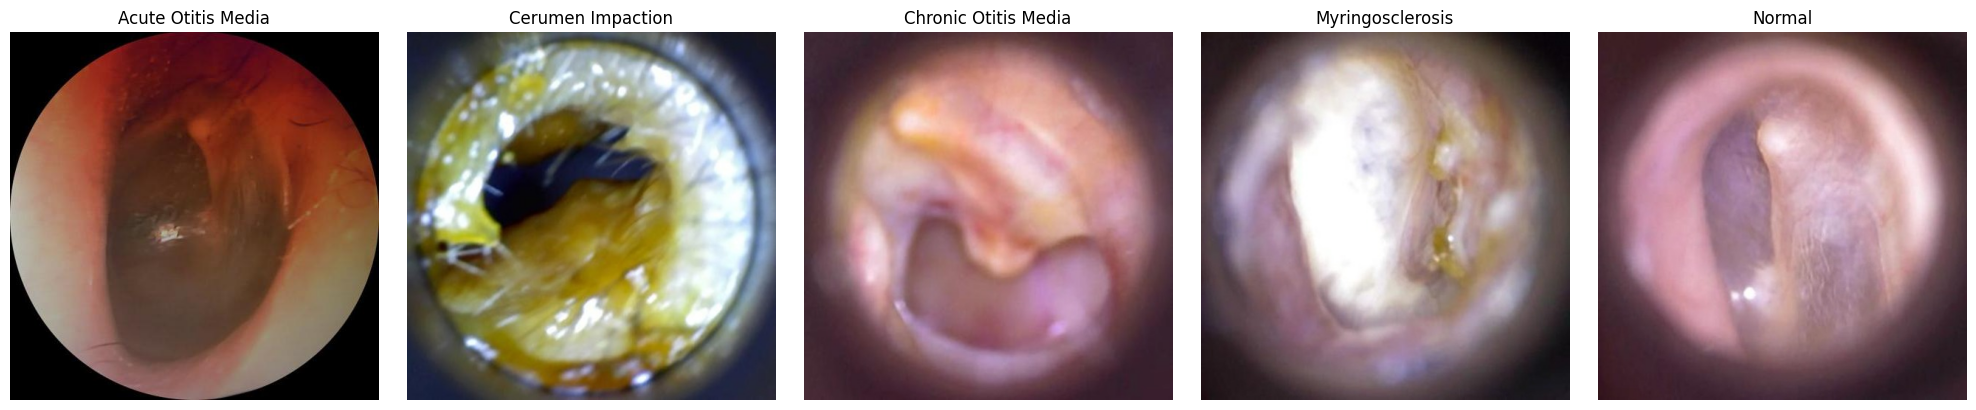

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = Image.open(image_path)

    axes[i].imshow(image)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

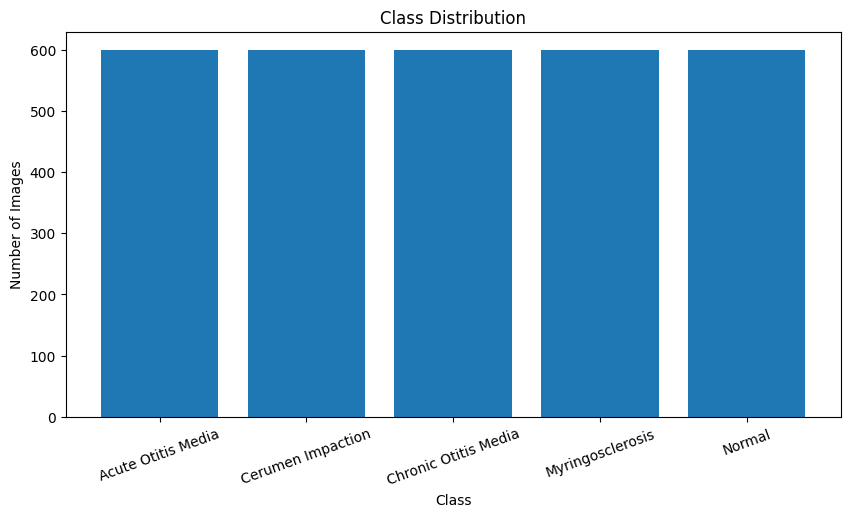

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.xticks(rotation=20)
plt.show()

In [7]:
image_sizes = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sizes = []

    for file in image_files:
        image_path = os.path.join(class_path, file)

        with Image.open(image_path) as image:
            sizes.append(image.size)

    image_sizes[class_name] = set(sizes)

for class_name, sizes in image_sizes.items():
    print(class_name, ":", sizes)

Acute Otitis Media : {(500, 500)}
Cerumen Impaction : {(500, 500)}
Chronic Otitis Media : {(500, 500)}
Myringosclerosis : {(500, 500)}
Normal : {(500, 500)}


In [8]:
channel_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    modes = set()

    for file in image_files[:50]:
        image_path = os.path.join(class_path, file)

        with Image.open(image_path) as image:
            modes.add(image.mode)

    channel_counts[class_name] = modes

for class_name, modes in channel_counts.items():
    print(class_name, ":", modes)

Acute Otitis Media : {'RGB'}
Cerumen Impaction : {'RGB'}
Chronic Otitis Media : {'RGB'}
Myringosclerosis : {'RGB'}
Normal : {'RGB'}


In [9]:
from collections import Counter

size_counter = Counter()

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        with Image.open(image_path) as image:
            size_counter[image.size] += 1

print("Image dimensions:")
for size, count in size_counter.items():
    print(size, ":", count)

Image dimensions:
(500, 500) : 3000


In [10]:
from PIL import Image
import os

corrupted_images = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        try:
            with Image.open(image_path) as image:
                image.verify()

        except Exception as e:
            corrupted_images.append(image_path)

print("Total corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted files:")
    for image in corrupted_images:
        print(image)

Total corrupted images: 0


In [11]:
import hashlib
from collections import defaultdict

image_hashes = defaultdict(list)

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        image_hashes[file_hash].append(image_path)

duplicate_groups = {
    h: paths
    for h, paths in image_hashes.items()
    if len(paths) > 1
}

print("Total unique images:", len(image_hashes))
print("Duplicate groups:", len(duplicate_groups))

duplicate_count = sum(len(paths) - 1 for paths in duplicate_groups.values())

print("Duplicate images:", duplicate_count)

Total unique images: 2922
Duplicate groups: 78
Duplicate images: 78


In [12]:
from collections import defaultdict
import hashlib
import os

image_hashes = defaultdict(list)

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        image_hashes[file_hash].append((class_name, image_path))


duplicate_groups = {
    h: items
    for h, items in image_hashes.items()
    if len(items) > 1
}

same_class_duplicates = []
cross_class_duplicates = []

for file_hash, items in duplicate_groups.items():

    classes_in_group = set(class_name for class_name, _ in items)

    if len(classes_in_group) == 1:
        same_class_duplicates.append(items)
    else:
        cross_class_duplicates.append(items)


print("Duplicate groups:", len(duplicate_groups))
print("Same-class duplicate groups:", len(same_class_duplicates))
print("Cross-class duplicate groups:", len(cross_class_duplicates))

Duplicate groups: 78
Same-class duplicate groups: 78
Cross-class duplicate groups: 0


In [13]:
print("\nCross-class duplicate details:\n")

for group in cross_class_duplicates:
    print("-" * 70)

    for class_name, image_path in group:
        print(class_name, "->", os.path.basename(image_path))


Cross-class duplicate details:



In [14]:
duplicate_by_class = defaultdict(int)

for group in same_class_duplicates:
    class_name = group[0][0]

    # Number of extra copies
    duplicate_by_class[class_name] += len(group) - 1

print("Duplicate copies by class:\n")

for class_name in classes:
    print(
        f"{class_name}: "
        f"{duplicate_by_class[class_name]} duplicate copies"
    )

print("\nTotal duplicate copies:",
      sum(duplicate_by_class.values()))

Duplicate copies by class:

Acute Otitis Media: 78 duplicate copies
Cerumen Impaction: 0 duplicate copies
Chronic Otitis Media: 0 duplicate copies
Myringosclerosis: 0 duplicate copies
Normal: 0 duplicate copies

Total duplicate copies: 78


In [15]:
import os
import shutil
import hashlib
from collections import defaultdict

clean_dataset_path = "/content/clean_otoscopic_dataset"

os.makedirs(clean_dataset_path, exist_ok=True)

# Store hashes we have already seen
seen_hashes = set()

# Create class folders
for class_name in classes:
    os.makedirs(
        os.path.join(clean_dataset_path, class_name),
        exist_ok=True
    )

# Copy only unique images
for class_name in classes:

    source_class_path = os.path.join(dataset_path, class_name)
    target_class_path = os.path.join(clean_dataset_path, class_name)

    image_files = [
        file for file in os.listdir(source_class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in image_files:

        source_path = os.path.join(source_class_path, file)

        # Calculate image file hash
        with open(source_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        # Skip duplicate
        if file_hash in seen_hashes:
            continue

        seen_hashes.add(file_hash)

        target_path = os.path.join(target_class_path, file)

        shutil.copy2(source_path, target_path)

print("Clean dataset created successfully.")
print("Unique images:", len(seen_hashes))

Clean dataset created successfully.
Unique images: 2922


In [16]:
clean_counts = {}

for class_name in classes:

    class_path = os.path.join(
        clean_dataset_path,
        class_name
    )

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    clean_counts[class_name] = len(images)

print("Clean dataset:")
print()

for class_name, count in clean_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal:", sum(clean_counts.values()))

Clean dataset:

Acute Otitis Media: 522
Cerumen Impaction: 600
Chronic Otitis Media: 600
Myringosclerosis: 600
Normal: 600

Total: 2922


**Train / Validation / Test Split**

70% Training
15% Validation
15% Testing

In [17]:
import pandas as pd
import os

data = []

for class_name in classes:

    class_path = os.path.join(
        clean_dataset_path,
        class_name
    )

    for file in os.listdir(class_path):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(
                class_path,
                file
            )

            data.append({
                "image_path": image_path,
                "label": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Total images: 2922

Class distribution:
label
Cerumen Impaction       600
Myringosclerosis        600
Chronic Otitis Media    600
Normal                  600
Acute Otitis Media      522
Name: count, dtype: int64


In [18]:
class_names = sorted(df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Class mapping:")

for class_name, idx in class_to_idx.items():
    print(idx, "->", class_name)

Class mapping:
0 -> Acute Otitis Media
1 -> Cerumen Impaction
2 -> Chronic Otitis Media
3 -> Myringosclerosis
4 -> Normal


In [19]:
df["label_id"] = df["label"].map(class_to_idx)

print(df.head())

                                          image_path               label  \
0  /content/clean_otoscopic_dataset/Acute Otitis ...  Acute Otitis Media   
1  /content/clean_otoscopic_dataset/Acute Otitis ...  Acute Otitis Media   
2  /content/clean_otoscopic_dataset/Acute Otitis ...  Acute Otitis Media   
3  /content/clean_otoscopic_dataset/Acute Otitis ...  Acute Otitis Media   
4  /content/clean_otoscopic_dataset/Acute Otitis ...  Acute Otitis Media   

   label_id  
0         0  
1         0  
2         0  
3         0  
4         0  


In [20]:
from sklearn.model_selection import train_test_split

# First split:
# 70% train
# 30% temporary

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Second split:
# Split the 30% temporary set equally
# 15% validation
# 15% test

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 2045
Validation: 438
Testing: 439


In [21]:
print("TRAINING")
print(train_df["label"].value_counts())

print("\nVALIDATION")
print(val_df["label"].value_counts())

print("\nTESTING")
print(test_df["label"].value_counts())

TRAINING
label
Cerumen Impaction       420
Chronic Otitis Media    420
Normal                  420
Myringosclerosis        420
Acute Otitis Media      365
Name: count, dtype: int64

VALIDATION
label
Normal                  90
Myringosclerosis        90
Cerumen Impaction       90
Chronic Otitis Media    90
Acute Otitis Media      78
Name: count, dtype: int64

TESTING
label
Myringosclerosis        90
Cerumen Impaction       90
Normal                  90
Chronic Otitis Media    90
Acute Otitis Media      79
Name: count, dtype: int64


In [22]:
split_dir = "/content/dataset_split"

os.makedirs(split_dir, exist_ok=True)

train_df.to_csv(
    os.path.join(split_dir, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(split_dir, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(split_dir, "test.csv"),
    index=False
)

print("Dataset splits saved.")

Dataset splits saved.


**PyTorch Dataset & DataLoader**

In [23]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130
GPU available: True
GPU: Tesla T4


In [24]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
from torch.utils.data import Dataset
from PIL import Image

class EarDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = int(row["label_id"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [27]:
train_dataset = EarDataset(
    train_df,
    transform=train_transform
)

val_dataset = EarDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = EarDataset(
    test_df,
    transform=val_test_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))

Training images: 2045
Validation images: 438
Testing images: 439


In [28]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


In [29]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([2, 2, 1, 3, 0, 1, 4, 4, 2, 2, 1, 1, 0, 1, 1, 1, 2, 4, 0, 1, 2, 2, 2, 0,
        0, 0, 1, 4, 0, 3, 1, 0])


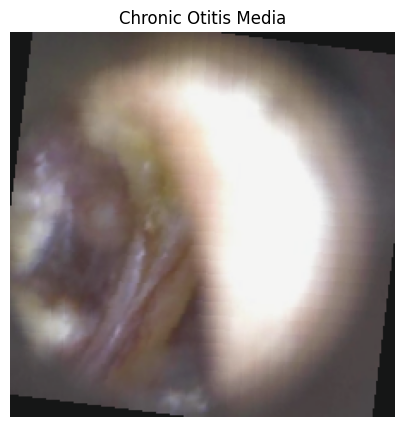

In [30]:
import matplotlib.pyplot as plt
import numpy as np

image = images[0].permute(1, 2, 0).numpy()
label = labels[0].item()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = image * std + mean
image = np.clip(image, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(idx_to_class[label])
plt.axis("off")
plt.show()

**Model 1: ResNet18**

In [31]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

NUM_CLASSES = 5
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

Device: cuda
GPU: Tesla T4


In [32]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [33]:
import torch.nn as nn

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=5, bias=True)


In [34]:
criterion = nn.CrossEntropyLoss()

In [35]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [36]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [37]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 5])


In [38]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [39]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [41]:
NUM_EPOCHS = 5

In [42]:
import copy
import time

best_val_loss = float("inf")
best_model_state = None

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        print("  → Best model updated")

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}% | "
        f"Time: {epoch_time:.1f}s"
    )

total_time = time.time() - start_time

print(f"\nTotal training time: {total_time / 60:.2f} minutes")

  → Best model updated
Epoch [1/5] | Train Loss: 0.0081 | Train Acc: 99.80% | Val Loss: 0.0018 | Val Acc: 100.00% | Time: 17.1s
Epoch [2/5] | Train Loss: 0.0080 | Train Acc: 99.80% | Val Loss: 0.0023 | Val Acc: 100.00% | Time: 15.0s
  → Best model updated
Epoch [3/5] | Train Loss: 0.0028 | Train Acc: 100.00% | Val Loss: 0.0003 | Val Acc: 100.00% | Time: 15.3s
Epoch [4/5] | Train Loss: 0.0020 | Train Acc: 99.95% | Val Loss: 0.0004 | Val Acc: 100.00% | Time: 14.8s
Epoch [5/5] | Train Loss: 0.0009 | Train Acc: 100.00% | Val Loss: 0.0009 | Val Acc: 100.00% | Time: 15.0s

Total training time: 1.29 minutes


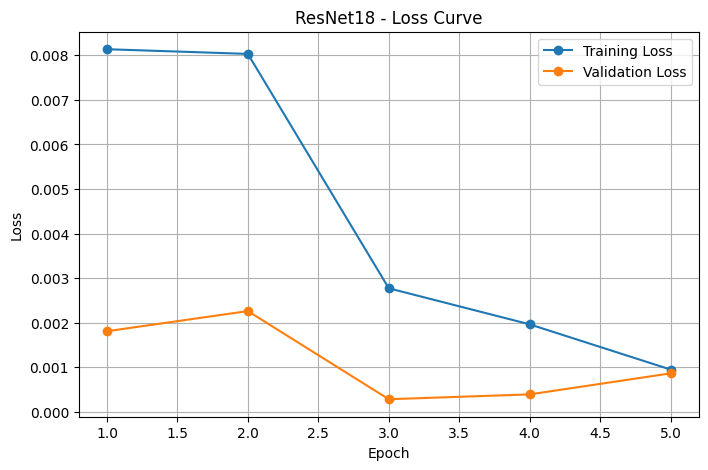

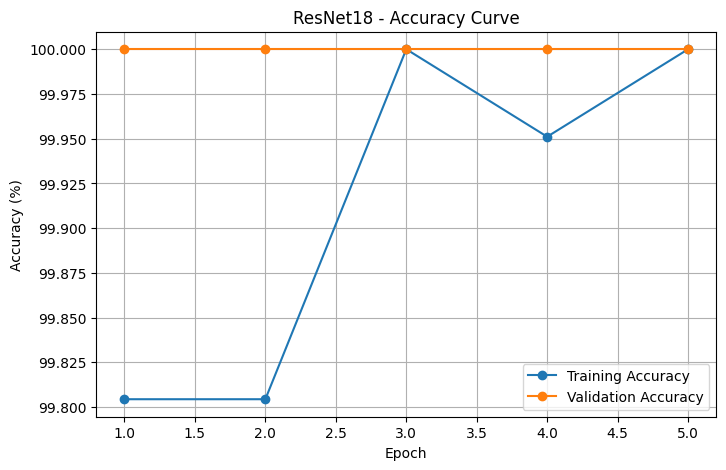

In [43]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 - Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in history["train_accuracy"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in history["val_accuracy"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 - Accuracy Curve")
plt.legend()
plt.grid(True)

plt.show()

In [46]:
model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

Best validation loss: 0.00010094701694686085


In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, loader, device):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return all_labels, all_predictions, accuracy

In [48]:
test_labels, test_predictions, test_accuracy = evaluate_model(
    model,
    test_loader,
    device
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 100.00%


In [49]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    1.0000    1.0000        79
   Cerumen Impaction     1.0000    1.0000    1.0000        90
Chronic Otitis Media     1.0000    1.0000    1.0000        90
    Myringosclerosis     1.0000    1.0000    1.0000        90
              Normal     1.0000    1.0000    1.0000        90

            accuracy                         1.0000       439
           macro avg     1.0000    1.0000    1.0000       439
        weighted avg     1.0000    1.0000    1.0000       439



In [50]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[79  0  0  0  0]
 [ 0 90  0  0  0]
 [ 0  0 90  0  0]
 [ 0  0  0 90  0]
 [ 0  0  0  0 90]]


1. Underfitting?        No
2. Obvious overfitting? No
3. Training working?    Yes
4. Test evaluation?     Yes
5. 100% result?         Needs investigation
5. 20 epochs?           Not yet





In [51]:
!pip install ImageHash -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.9 MB/s eta 0:00:00


In [52]:
import imagehash
from PIL import Image
import os

In [53]:
def get_phash(image_path):
    image = Image.open(image_path).convert("RGB")
    return imagehash.phash(image)


train_hashes = {}

for _, row in train_df.iterrows():
    image_path = row["image_path"]
    train_hashes[image_path] = get_phash(image_path)

print("Training images hashed:", len(train_hashes))

Training images hashed: 2045


In [54]:
val_hashes = {}

for _, row in val_df.iterrows():
    image_path = row["image_path"]
    val_hashes[image_path] = get_phash(image_path)

print("Validation images hashed:", len(val_hashes))

Validation images hashed: 438


In [55]:
test_hashes = {}

for _, row in test_df.iterrows():
    image_path = row["image_path"]
    test_hashes[image_path] = get_phash(image_path)

print("Test images hashed:", len(test_hashes))

Test images hashed: 439


In [56]:
suspicious_pairs = []

for test_path, test_hash in test_hashes.items():

    for train_path, train_hash in train_hashes.items():

        distance = test_hash - train_hash

        if distance <= 5:

            suspicious_pairs.append({
                "test": test_path,
                "train": train_path,
                "distance": distance
            })

print("Suspicious train-test pairs:", len(suspicious_pairs))

Suspicious train-test pairs: 361


In [57]:
from collections import Counter

# Count suspicious pairs by perceptual distance
distance_counts = Counter()

for test_path, test_hash in test_hashes.items():

    for train_path, train_hash in train_hashes.items():

        distance = test_hash - train_hash

        if distance <= 5:
            distance_counts[distance] += 1

print("Perceptual hash distance distribution:")

for distance in sorted(distance_counts):
    print(
        f"Distance {distance}: "
        f"{distance_counts[distance]} pairs"
    )

Perceptual hash distance distribution:
Distance 0: 47 pairs
Distance 2: 148 pairs
Distance 4: 166 pairs


In [58]:
suspicious_test_images = set()

for test_path, test_hash in test_hashes.items():

    for train_path, train_hash in train_hashes.items():

        distance = test_hash - train_hash

        if distance <= 5:
            suspicious_test_images.add(test_path)

print(
    "Unique suspicious test images:",
    len(suspicious_test_images)
)

print(
    "Total test images:",
    len(test_hashes)
)

print(
    "Percentage of test images with suspicious matches:",
    len(suspicious_test_images) / len(test_hashes) * 100
)

Unique suspicious test images: 185
Total test images: 439
Percentage of test images with suspicious matches: 42.14123006833713


In [59]:
suspicious_class_counts = Counter()

for image_path in suspicious_test_images:

    row = test_df[test_df["image_path"] == image_path].iloc[0]

    suspicious_class_counts[row["label"]] += 1

print("\nSuspicious test images by class:")

for class_name in class_names:
    print(
        class_name,
        ":",
        suspicious_class_counts[class_name]
    )


Suspicious test images by class:
Acute Otitis Media : 1
Cerumen Impaction : 58
Chronic Otitis Media : 25
Myringosclerosis : 49
Normal : 52


In [60]:
from collections import Counter

distance_counts = Counter()

for test_path, test_hash in test_hashes.items():

    for train_path, train_hash in train_hashes.items():

        distance = test_hash - train_hash

        if distance <= 5:
            distance_counts[distance] += 1

print("Perceptual hash distance distribution:\n")

for distance in sorted(distance_counts):
    print(
        f"Distance {distance}: "
        f"{distance_counts[distance]} pairs"
    )

Perceptual hash distance distribution:

Distance 0: 47 pairs
Distance 2: 148 pairs
Distance 4: 166 pairs


In [61]:
all_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("Total images:", len(all_df))

Total images: 2922


In [62]:
import imagehash
from PIL import Image

all_hashes = {}

for image_path in all_df["image_path"]:

    image = Image.open(image_path).convert("RGB")

    all_hashes[image_path] = imagehash.phash(image)

print("Images hashed:", len(all_hashes))

Images hashed: 2922


In [63]:
class UnionFind:

    def __init__(self, items):
        self.parent = {item: item for item in items}

    def find(self, item):
        if self.parent[item] != item:
            self.parent[item] = self.find(self.parent[item])

        return self.parent[item]

    def union(self, a, b):

        root_a = self.find(a)
        root_b = self.find(b)

        if root_a != root_b:
            self.parent[root_b] = root_a

In [64]:
from collections import defaultdict

image_paths = list(all_hashes.keys())

uf = UnionFind(image_paths)

threshold = 4

for i in range(len(image_paths)):

    hash_i = all_hashes[image_paths[i]]

    for j in range(i + 1, len(image_paths)):

        hash_j = all_hashes[image_paths[j]]

        distance = hash_i - hash_j

        if distance <= threshold:
            uf.union(
                image_paths[i],
                image_paths[j]
            )

print("Near-duplicate grouping completed.")

Near-duplicate grouping completed.


In [65]:
groups = defaultdict(list)

for image_path in image_paths:

    root = uf.find(image_path)

    groups[root].append(image_path)

duplicate_groups = [
    group
    for group in groups.values()
    if len(group) > 1
]

print("Total groups:", len(groups))
print("Near-duplicate groups:", len(duplicate_groups))

Total groups: 1924
Near-duplicate groups: 509


In [66]:
group_sizes = sorted(
    [len(group) for group in duplicate_groups],
    reverse=True
)

print("Largest near-duplicate groups:")

for size in group_sizes[:20]:
    print(size)

Largest near-duplicate groups:
10
10
10
10
10
10
8
8
7
7
7
7
7
7
7
7
7
7
7
6


In [67]:
cross_class_groups = []

for group in duplicate_groups:

    group_classes = set()

    for image_path in group:

        row = all_df[
            all_df["image_path"] == image_path
        ].iloc[0]

        group_classes.add(row["label"])

    if len(group_classes) > 1:

        cross_class_groups.append(
            (group, group_classes)
        )

print(
    "Cross-class near-duplicate groups:",
    len(cross_class_groups)
)

Cross-class near-duplicate groups: 0


In [68]:
print("Total images:", len(all_df))
print("Images hashed:", len(all_hashes))
print("Total groups:", len(groups))
print("Near-duplicate groups:", len(duplicate_groups))

print("\nLargest near-duplicate groups:")
for size in group_sizes[:20]:
    print(size)

print("\nCross-class near-duplicate groups:", len(cross_class_groups))

Total images: 2922
Images hashed: 2922
Total groups: 1924
Near-duplicate groups: 509

Largest near-duplicate groups:
10
10
10
10
10
10
8
8
7
7
7
7
7
7
7
7
7
7
7
6

Cross-class near-duplicate groups: 0


leakage-safe split

In [69]:
from sklearn.model_selection import StratifiedGroupKFold

# Create mapping: image path -> group ID

path_to_group = {}

for group_id, group in enumerate(groups.values()):

    for image_path in group:
        path_to_group[image_path] = group_id

all_df["group_id"] = all_df["image_path"].map(path_to_group)

print("Total images:", len(all_df))
print("Unique groups:", all_df["group_id"].nunique())

Total images: 2922
Unique groups: 1924


In [70]:
sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

folds = list(
    sgkf.split(
        all_df,
        all_df["label_id"],
        groups=all_df["group_id"]
    )
)

print("Created", len(folds), "group-aware folds.")

Created 10 group-aware folds.


In [71]:
temp_fold_ids = {0, 1, 2}

temp_indices = []
train_indices = []

for fold_id, (train_idx, val_idx) in enumerate(folds):

    if fold_id in temp_fold_ids:
        temp_indices.extend(val_idx)
    else:
        train_indices.extend(val_idx)

train_group_df = all_df.iloc[train_indices].copy()
temp_group_df = all_df.iloc[temp_indices].copy()

print("Training images:", len(train_group_df))
print("Temporary images:", len(temp_group_df))

Training images: 2059
Temporary images: 863


In [72]:
temp_sgkf = StratifiedGroupKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

temp_splits = list(
    temp_sgkf.split(
        temp_group_df,
        temp_group_df["label_id"],
        groups=temp_group_df["group_id"]
    )
)

val_idx, test_idx = temp_splits[0]

val_group_df = temp_group_df.iloc[val_idx].copy()
test_group_df = temp_group_df.iloc[test_idx].copy()

print("Train:", len(train_group_df))
print("Validation:", len(val_group_df))
print("Test:", len(test_group_df))

Train: 2059
Validation: 418
Test: 445


In [73]:
print("TRAINING")
print(train_group_df["label"].value_counts())
print()

print("VALIDATION")
print(val_group_df["label"].value_counts())
print()

print("TEST")
print(test_group_df["label"].value_counts())

TRAINING
label
Chronic Otitis Media    444
Myringosclerosis        435
Cerumen Impaction       414
Normal                  403
Acute Otitis Media      363
Name: count, dtype: int64

VALIDATION
label
Normal                  103
Cerumen Impaction        97
Acute Otitis Media       80
Chronic Otitis Media     80
Myringosclerosis         58
Name: count, dtype: int64

TEST
label
Myringosclerosis        107
Normal                   94
Cerumen Impaction        89
Acute Otitis Media       79
Chronic Otitis Media     76
Name: count, dtype: int64


In [74]:
train_groups = set(train_group_df["group_id"])
val_groups = set(val_group_df["group_id"])
test_groups = set(test_group_df["group_id"])

print("Train ∩ Validation:",
      len(train_groups & val_groups))

print("Train ∩ Test:",
      len(train_groups & test_groups))

print("Validation ∩ Test:",
      len(val_groups & test_groups))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [75]:
final_split_dir = "/content/leakage_safe_split"

os.makedirs(final_split_dir, exist_ok=True)

train_group_df.to_csv(
    os.path.join(final_split_dir, "train.csv"),
    index=False
)

val_group_df.to_csv(
    os.path.join(final_split_dir, "validation.csv"),
    index=False
)

test_group_df.to_csv(
    os.path.join(final_split_dir, "test.csv"),
    index=False
)

print("Leakage-safe split saved successfully.")

Leakage-safe split saved successfully.


In [76]:
import pandas as pd
import os

final_split_dir = "/content/leakage_safe_split"

train_df = pd.read_csv(
    os.path.join(final_split_dir, "train.csv")
)

val_df = pd.read_csv(
    os.path.join(final_split_dir, "validation.csv")
)

test_df = pd.read_csv(
    os.path.join(final_split_dir, "test.csv")
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nClass distribution:")
print("\nTrain:")
print(train_df["label"].value_counts())

print("\nValidation:")
print(val_df["label"].value_counts())

print("\nTest:")
print(test_df["label"].value_counts())

Train: 2059
Validation: 418
Test: 445

Class distribution:

Train:
label
Chronic Otitis Media    444
Myringosclerosis        435
Cerumen Impaction       414
Normal                  403
Acute Otitis Media      363
Name: count, dtype: int64

Validation:
label
Normal                  103
Cerumen Impaction        97
Acute Otitis Media       80
Chronic Otitis Media     80
Myringosclerosis         58
Name: count, dtype: int64

Test:
label
Myringosclerosis        107
Normal                   94
Cerumen Impaction        89
Acute Otitis Media       79
Chronic Otitis Media     76
Name: count, dtype: int64


In [77]:
print(train_df.head())
print(train_df.columns)

                                          image_path                 label  \
0  /content/clean_otoscopic_dataset/Chronic Otiti...  Chronic Otitis Media   
1  /content/clean_otoscopic_dataset/Acute Otitis ...    Acute Otitis Media   
2  /content/clean_otoscopic_dataset/Chronic Otiti...  Chronic Otitis Media   
3  /content/clean_otoscopic_dataset/Acute Otitis ...    Acute Otitis Media   
4  /content/clean_otoscopic_dataset/Normal/norm (...                Normal   

   label_id  group_id  
0         2         8  
1         0         9  
2         2        11  
3         0        33  
4         4        36  
Index(['image_path', 'label', 'label_id', 'group_id'], dtype='object')


Recreate the datasets

In [78]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class EarDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = int(row["label_id"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [79]:
train_dataset = EarDataset(
    train_df,
    transform=train_transform
)

val_dataset = EarDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = EarDataset(
    test_df,
    transform=val_test_transform
)

In [81]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [82]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=5, bias=True)


In [83]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

Test for 5 epochs again

In [84]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [85]:
import time
import copy

NUM_EPOCHS = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_loss = float("inf")
best_model_state = None

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

training_time = (time.time() - start_time) / 60

print(f"\nTraining time: {training_time:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.6f}")

Epoch [1/5] | Train Loss: 0.2775 | Train Acc: 90.77% | Val Loss: 0.0210 | Val Acc: 100.00% | LR: 0.000100
Epoch [2/5] | Train Loss: 0.0318 | Train Acc: 99.08% | Val Loss: 0.0088 | Val Acc: 100.00% | LR: 0.000100
Epoch [3/5] | Train Loss: 0.0181 | Train Acc: 99.56% | Val Loss: 0.1142 | Val Acc: 94.74% | LR: 0.000100
Epoch [4/5] | Train Loss: 0.0077 | Train Acc: 99.95% | Val Loss: 0.0046 | Val Acc: 100.00% | LR: 0.000100
Epoch [5/5] | Train Loss: 0.0072 | Train Acc: 99.76% | Val Loss: 0.0027 | Val Acc: 100.00% | LR: 0.000100

Training time: 1.29 minutes
Best validation loss: 0.002741


In [86]:
model.load_state_dict(best_model_state)

torch.save(
    model.state_dict(),
    "/content/resnet18_leakage_safe_best.pth"
)

print("Best ResNet18 model saved.")

Best ResNet18 model saved.


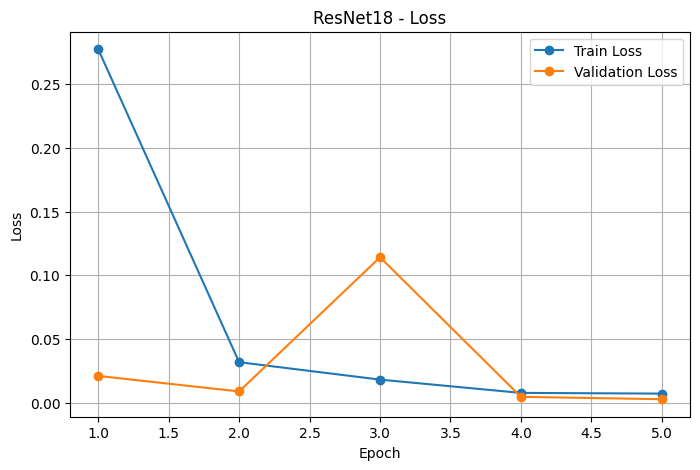

In [87]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 - Loss")
plt.legend()
plt.grid()

plt.show()

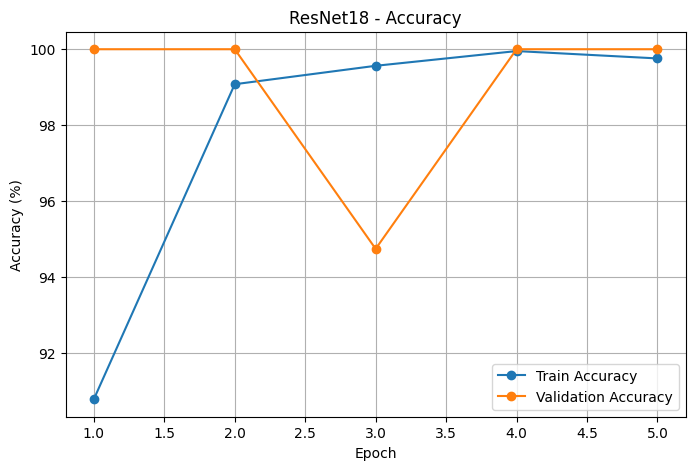

In [88]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in train_accuracies],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in val_accuracies],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 - Accuracy")
plt.legend()
plt.grid()

plt.show()

continue to 20 Epochs for reverify

In [89]:
TOTAL_EPOCHS = 20
PATIENCE = 4

best_val_loss = min(val_losses)
best_model_state = copy.deepcopy(model.state_dict())

epochs_without_improvement = 0

start_epoch = 5

for epoch in range(start_epoch, TOTAL_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        best_marker = " <-- BEST"
    else:
        epochs_without_improvement += 1
        best_marker = ""

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
        f"{best_marker}"
    )

    if epochs_without_improvement >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

Epoch [6/20] | Train Loss: 0.0318 | Train Acc: 98.93% | Val Loss: 0.0045 | Val Acc: 100.00% | LR: 0.000100
Epoch [7/20] | Train Loss: 0.0129 | Train Acc: 99.61% | Val Loss: 0.0022 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [8/20] | Train Loss: 0.0101 | Train Acc: 99.66% | Val Loss: 0.0026 | Val Acc: 100.00% | LR: 0.000100
Epoch [9/20] | Train Loss: 0.0078 | Train Acc: 99.76% | Val Loss: 0.0013 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [10/20] | Train Loss: 0.0120 | Train Acc: 99.56% | Val Loss: 0.0122 | Val Acc: 99.52% | LR: 0.000100
Epoch [11/20] | Train Loss: 0.0067 | Train Acc: 99.76% | Val Loss: 0.0041 | Val Acc: 100.00% | LR: 0.000100
Epoch [12/20] | Train Loss: 0.0040 | Train Acc: 99.95% | Val Loss: 0.0018 | Val Acc: 100.00% | LR: 0.000050
Epoch [13/20] | Train Loss: 0.0024 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 100.00% | LR: 0.000050 <-- BEST
Epoch [14/20] | Train Loss: 0.0017 | Train Acc: 100.00% | Val Loss: 0.0006 | Val Acc: 100.00% | LR: 0.000050
Epoc

In [90]:
model.load_state_dict(best_model_state)

torch.save(
    model.state_dict(),
    "/content/resnet18_leakage_safe_best.pth"
)

print("Best ResNet18 checkpoint saved.")
print("Best validation loss:", best_val_loss)

Best ResNet18 checkpoint saved.
Best validation loss: 0.0005177624470932503


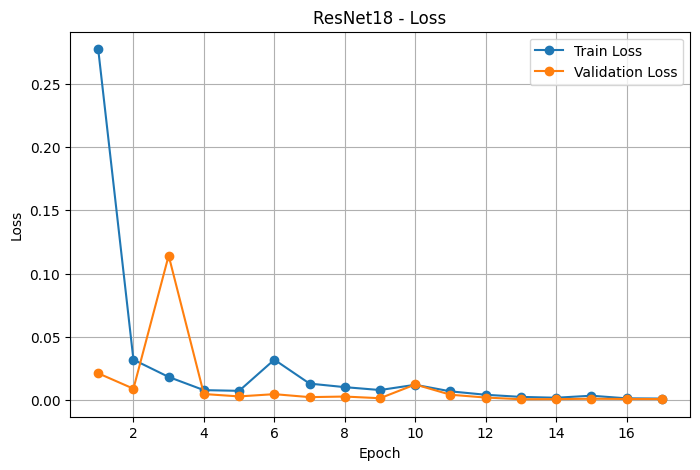

In [91]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 - Loss")
plt.legend()
plt.grid()
plt.show()

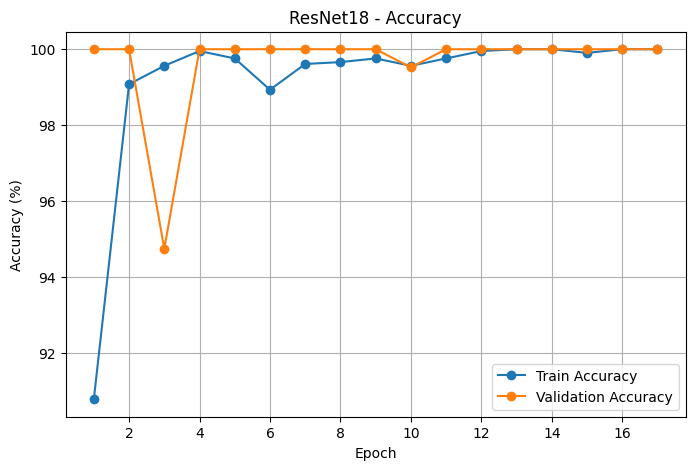

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in train_accuracies],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in val_accuracies],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 - Accuracy")
plt.legend()
plt.grid()
plt.show()

In [93]:
model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

Best validation loss: 0.0005177624470932503


In [94]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"ResNet18 Test Accuracy: {test_accuracy * 100:.2f}%")

ResNet18 Test Accuracy: 99.78%


In [95]:
class_names = sorted(train_df["label"].unique())

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    1.0000    1.0000        79
   Cerumen Impaction     1.0000    1.0000    1.0000        89
Chronic Otitis Media     1.0000    1.0000    1.0000        76
    Myringosclerosis     1.0000    0.9907    0.9953       107
              Normal     0.9895    1.0000    0.9947        94

            accuracy                         0.9978       445
           macro avg     0.9979    0.9981    0.9980       445
        weighted avg     0.9978    0.9978    0.9978       445



In [96]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 79   0   0   0   0]
 [  0  89   0   0   0]
 [  0   0  76   0   0]
 [  0   0   0 106   1]
 [  0   0   0   0  94]]


**MobileNetV3-Large**

In [97]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
import torch.nn as nn

weights = MobileNet_V3_Large_Weights.DEFAULT

mobilenet = mobilenet_v3_large(weights=weights)

num_features = mobilenet.classifier[-1].in_features

mobilenet.classifier[-1] = nn.Linear(
    num_features,
    NUM_CLASSES
)

mobilenet = mobilenet.to(device)

print(mobilenet.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 129MB/s]


Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=5, bias=True)
)


In [98]:
mobile_criterion = nn.CrossEntropyLoss()

mobile_optimizer = torch.optim.AdamW(
    mobilenet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

mobile_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    mobile_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

MobileNetV3-Large: first 5 epochs

In [99]:
mobile_train_losses = []
mobile_train_accuracies = []

mobile_val_losses = []
mobile_val_accuracies = []

mobile_best_val_loss = float("inf")
mobile_best_model_state = None

NUM_EPOCHS = 5

import copy
import time

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        mobilenet,
        train_loader,
        mobile_criterion,
        mobile_optimizer,
        device
    )

    val_loss, val_acc = validate(
        mobilenet,
        val_loader,
        mobile_criterion,
        device
    )

    mobile_scheduler.step(val_loss)

    mobile_train_losses.append(train_loss)
    mobile_train_accuracies.append(train_acc)

    mobile_val_losses.append(val_loss)
    mobile_val_accuracies.append(val_acc)

    if val_loss < mobile_best_val_loss:
        mobile_best_val_loss = val_loss
        mobile_best_model_state = copy.deepcopy(
            mobilenet.state_dict()
        )

    current_lr = mobile_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/5] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

training_time = (time.time() - start_time) / 60

print(f"\nTraining time: {training_time:.2f} minutes")
print(f"Best validation loss: {mobile_best_val_loss:.6f}")

Epoch [1/5] | Train Loss: 0.5951 | Train Acc: 84.12% | Val Loss: 0.2230 | Val Acc: 90.67% | LR: 0.000100
Epoch [2/5] | Train Loss: 0.0389 | Train Acc: 99.13% | Val Loss: 0.0339 | Val Acc: 99.04% | LR: 0.000100
Epoch [3/5] | Train Loss: 0.0127 | Train Acc: 99.56% | Val Loss: 0.0200 | Val Acc: 98.80% | LR: 0.000100
Epoch [4/5] | Train Loss: 0.0139 | Train Acc: 99.61% | Val Loss: 0.0040 | Val Acc: 100.00% | LR: 0.000100
Epoch [5/5] | Train Loss: 0.0155 | Train Acc: 99.61% | Val Loss: 0.0147 | Val Acc: 99.04% | LR: 0.000100

Training time: 1.36 minutes
Best validation loss: 0.004029


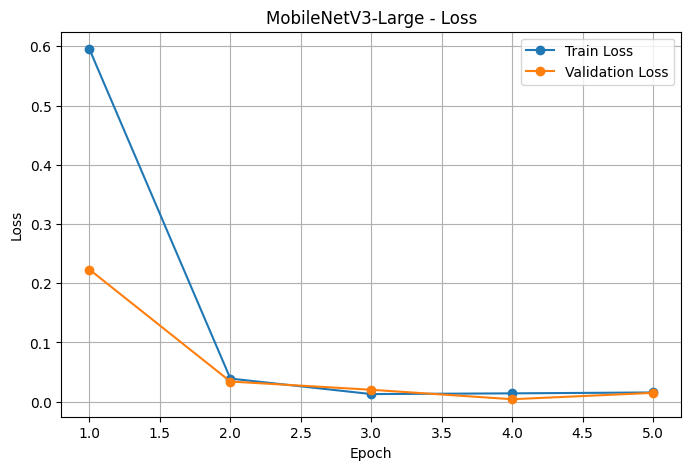

In [100]:
import matplotlib.pyplot as plt

epochs = range(1, len(mobile_train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    mobile_train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    mobile_val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV3-Large - Loss")
plt.legend()
plt.grid()

plt.show()

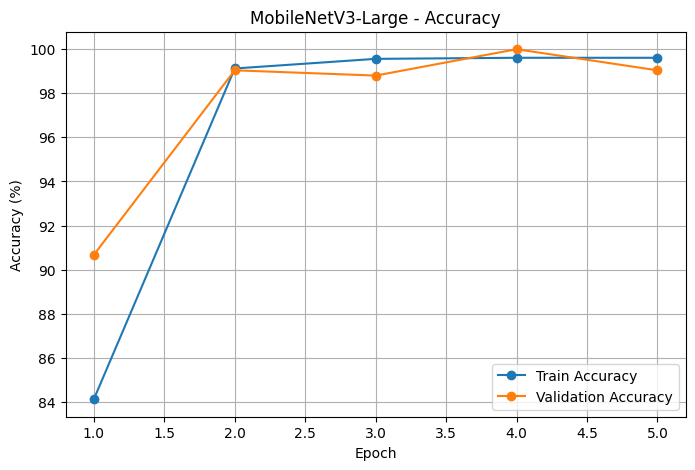

In [101]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in mobile_train_accuracies],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in mobile_val_accuracies],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("MobileNetV3-Large - Accuracy")
plt.legend()
plt.grid()

plt.show()

In [102]:
TOTAL_EPOCHS = 20
PATIENCE = 4

mobile_best_val_loss = min(mobile_val_losses)
mobile_best_model_state = copy.deepcopy(
    mobilenet.state_dict()
)

mobile_epochs_without_improvement = 0

start_epoch = 5

for epoch in range(start_epoch, TOTAL_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        mobilenet,
        train_loader,
        mobile_criterion,
        mobile_optimizer,
        device
    )

    val_loss, val_acc = validate(
        mobilenet,
        val_loader,
        mobile_criterion,
        device
    )

    mobile_scheduler.step(val_loss)

    mobile_train_losses.append(train_loss)
    mobile_train_accuracies.append(train_acc)

    mobile_val_losses.append(val_loss)
    mobile_val_accuracies.append(val_acc)

    if val_loss < mobile_best_val_loss:

        mobile_best_val_loss = val_loss

        mobile_best_model_state = copy.deepcopy(
            mobilenet.state_dict()
        )

        mobile_epochs_without_improvement = 0

        best_marker = " <-- BEST"

    else:

        mobile_epochs_without_improvement += 1

        best_marker = ""

    current_lr = mobile_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
        f"{best_marker}"
    )

    if mobile_epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break

Epoch [6/20] | Train Loss: 0.0116 | Train Acc: 99.71% | Val Loss: 0.0078 | Val Acc: 100.00% | LR: 0.000100
Epoch [7/20] | Train Loss: 0.0094 | Train Acc: 99.56% | Val Loss: 0.0020 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [8/20] | Train Loss: 0.0079 | Train Acc: 99.76% | Val Loss: 0.0465 | Val Acc: 98.33% | LR: 0.000100
Epoch [9/20] | Train Loss: 0.0043 | Train Acc: 99.95% | Val Loss: 0.0103 | Val Acc: 99.52% | LR: 0.000100
Epoch [10/20] | Train Loss: 0.0047 | Train Acc: 99.81% | Val Loss: 0.0006 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [11/20] | Train Loss: 0.0009 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [12/20] | Train Loss: 0.0004 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00% | LR: 0.000100
Epoch [13/20] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [14/20] | Train Loss: 0.0003 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00% | LR: 0.0

In [103]:
mobilenet.load_state_dict(
    mobile_best_model_state
)

torch.save(
    mobilenet.state_dict(),
    "/content/mobilenet_v3_large_leakage_safe_best.pth"
)

print("Best MobileNetV3-Large checkpoint saved.")
print(
    "Best validation loss:",
    mobile_best_val_loss
)

Best MobileNetV3-Large checkpoint saved.
Best validation loss: 2.356477800805681e-05


In [104]:
mobilenet.load_state_dict(mobile_best_model_state)
mobilenet.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [105]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

mobile_all_labels = []
mobile_all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = mobilenet(images)

        predictions = torch.argmax(outputs, dim=1)

        mobile_all_labels.extend(
            labels.cpu().numpy()
        )

        mobile_all_predictions.extend(
            predictions.cpu().numpy()
        )

mobile_test_accuracy = accuracy_score(
    mobile_all_labels,
    mobile_all_predictions
)

print(
    f"MobileNetV3-Large Test Accuracy: "
    f"{mobile_test_accuracy * 100:.2f}%"
)

MobileNetV3-Large Test Accuracy: 100.00%


In [106]:
print(
    classification_report(
        mobile_all_labels,
        mobile_all_predictions,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    1.0000    1.0000        79
   Cerumen Impaction     1.0000    1.0000    1.0000        89
Chronic Otitis Media     1.0000    1.0000    1.0000        76
    Myringosclerosis     1.0000    1.0000    1.0000       107
              Normal     1.0000    1.0000    1.0000        94

            accuracy                         1.0000       445
           macro avg     1.0000    1.0000    1.0000       445
        weighted avg     1.0000    1.0000    1.0000       445



In [107]:
mobile_cm = confusion_matrix(
    mobile_all_labels,
    mobile_all_predictions
)

print("Confusion Matrix:")
print(mobile_cm)

Confusion Matrix:
[[ 79   0   0   0   0]
 [  0  89   0   0   0]
 [  0   0  76   0   0]
 [  0   0   0 107   0]
 [  0   0   0   0  94]]


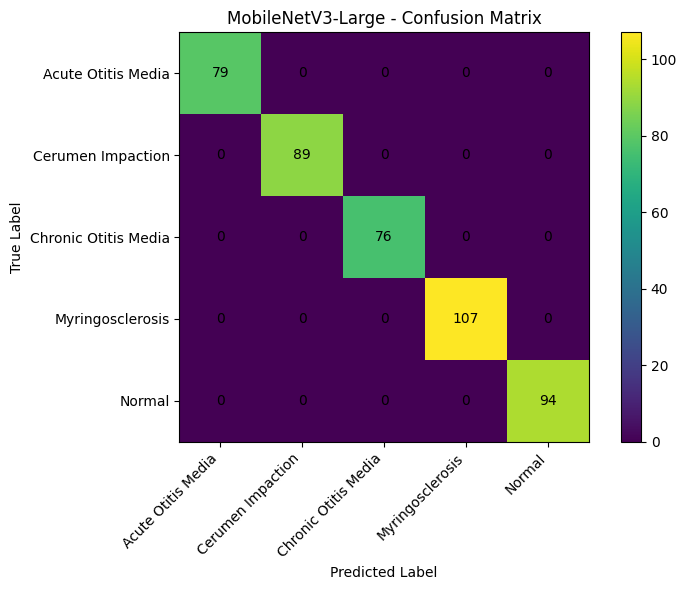

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(mobile_cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV3-Large - Confusion Matrix")

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            mobile_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

**EfficientNet-B0**

In [109]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

weights = EfficientNet_B0_Weights.DEFAULT

efficientnet = efficientnet_b0(weights=weights)

num_features = efficientnet.classifier[-1].in_features

efficientnet.classifier[-1] = nn.Linear(
    num_features,
    NUM_CLASSES
)

efficientnet = efficientnet.to(device)

print(efficientnet.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [110]:
efficient_criterion = nn.CrossEntropyLoss()

efficient_optimizer = torch.optim.AdamW(
    efficientnet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

efficient_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    efficient_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [111]:
efficient_train_losses = []
efficient_train_accuracies = []

efficient_val_losses = []
efficient_val_accuracies = []

efficient_best_val_loss = float("inf")
efficient_best_model_state = None

NUM_EPOCHS = 5

import copy
import time

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        efficientnet,
        train_loader,
        efficient_criterion,
        efficient_optimizer,
        device
    )

    val_loss, val_acc = validate(
        efficientnet,
        val_loader,
        efficient_criterion,
        device
    )

    efficient_scheduler.step(val_loss)

    efficient_train_losses.append(train_loss)
    efficient_train_accuracies.append(train_acc)

    efficient_val_losses.append(val_loss)
    efficient_val_accuracies.append(val_acc)

    if val_loss < efficient_best_val_loss:

        efficient_best_val_loss = val_loss

        efficient_best_model_state = copy.deepcopy(
            efficientnet.state_dict()
        )

    current_lr = efficient_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/5] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

training_time = (time.time() - start_time) / 60

print(f"\nTraining time: {training_time:.2f} minutes")
print(f"Best validation loss: {efficient_best_val_loss:.6f}")

Epoch [1/5] | Train Loss: 0.7769 | Train Acc: 81.88% | Val Loss: 0.1686 | Val Acc: 96.89% | LR: 0.000100
Epoch [2/5] | Train Loss: 0.1301 | Train Acc: 97.13% | Val Loss: 0.0310 | Val Acc: 99.76% | LR: 0.000100
Epoch [3/5] | Train Loss: 0.0523 | Train Acc: 99.13% | Val Loss: 0.0143 | Val Acc: 99.76% | LR: 0.000100
Epoch [4/5] | Train Loss: 0.0325 | Train Acc: 99.22% | Val Loss: 0.0061 | Val Acc: 100.00% | LR: 0.000100
Epoch [5/5] | Train Loss: 0.0220 | Train Acc: 99.61% | Val Loss: 0.0019 | Val Acc: 100.00% | LR: 0.000100

Training time: 1.50 minutes
Best validation loss: 0.001924


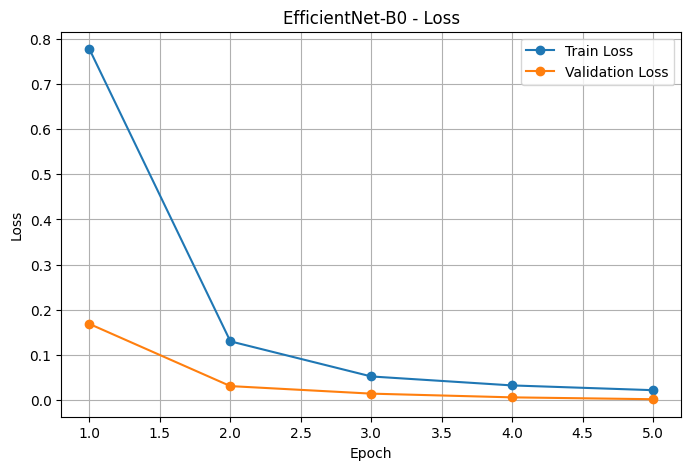

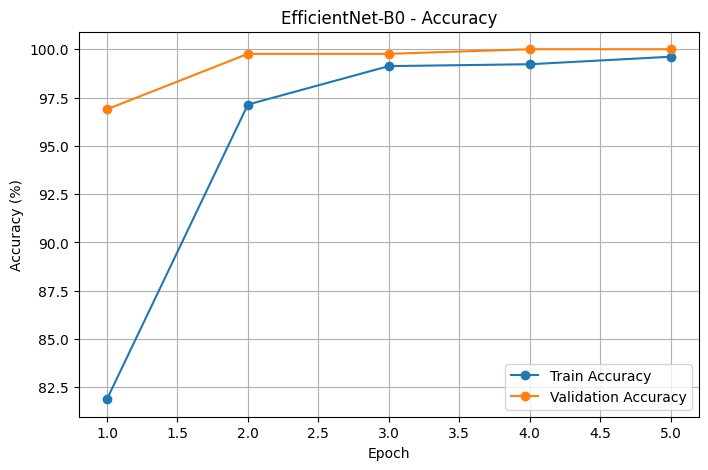

In [112]:
import matplotlib.pyplot as plt

epochs = range(1, len(efficient_train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    efficient_train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    efficient_val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 - Loss")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in efficient_train_accuracies],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in efficient_val_accuracies],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 - Accuracy")
plt.legend()
plt.grid()

plt.show()

In [113]:
TOTAL_EPOCHS = 20
PATIENCE = 4

efficient_best_val_loss = min(efficient_val_losses)

efficient_best_model_state = copy.deepcopy(
    efficientnet.state_dict()
)

efficient_epochs_without_improvement = 0

start_epoch = 5

for epoch in range(start_epoch, TOTAL_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        efficientnet,
        train_loader,
        efficient_criterion,
        efficient_optimizer,
        device
    )

    val_loss, val_acc = validate(
        efficientnet,
        val_loader,
        efficient_criterion,
        device
    )

    efficient_scheduler.step(val_loss)

    efficient_train_losses.append(train_loss)
    efficient_train_accuracies.append(train_acc)

    efficient_val_losses.append(val_loss)
    efficient_val_accuracies.append(val_acc)

    if val_loss < efficient_best_val_loss:

        efficient_best_val_loss = val_loss

        efficient_best_model_state = copy.deepcopy(
            efficientnet.state_dict()
        )

        efficient_epochs_without_improvement = 0

        best_marker = " <-- BEST"

    else:

        efficient_epochs_without_improvement += 1

        best_marker = ""

    current_lr = efficient_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
        f"{best_marker}"
    )

    if efficient_epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break

Epoch [6/20] | Train Loss: 0.0138 | Train Acc: 99.76% | Val Loss: 0.0012 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [7/20] | Train Loss: 0.0121 | Train Acc: 99.81% | Val Loss: 0.0012 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [8/20] | Train Loss: 0.0078 | Train Acc: 99.90% | Val Loss: 0.0013 | Val Acc: 100.00% | LR: 0.000100
Epoch [9/20] | Train Loss: 0.0108 | Train Acc: 99.61% | Val Loss: 0.0009 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [10/20] | Train Loss: 0.0136 | Train Acc: 99.61% | Val Loss: 0.0027 | Val Acc: 100.00% | LR: 0.000100
Epoch [11/20] | Train Loss: 0.0093 | Train Acc: 99.81% | Val Loss: 0.0006 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [12/20] | Train Loss: 0.0049 | Train Acc: 99.90% | Val Loss: 0.0008 | Val Acc: 100.00% | LR: 0.000100
Epoch [13/20] | Train Loss: 0.0029 | Train Acc: 100.00% | Val Loss: 0.0003 | Val Acc: 100.00% | LR: 0.000100 <-- BEST
Epoch [14/20] | Train Loss: 0.0035 | Train Acc: 100.00% | Val Loss: 0.0003 | Val Acc: 100.00% 

In [114]:
efficientnet.load_state_dict(
    efficient_best_model_state
)

torch.save(
    efficientnet.state_dict(),
    "/content/efficientnet_b0_leakage_safe_best.pth"
)

print("Best EfficientNet-B0 checkpoint saved.")
print(
    "Best validation loss:",
    efficient_best_val_loss
)

Best EfficientNet-B0 checkpoint saved.
Best validation loss: 7.397403631016917e-05


In [115]:
efficientnet.load_state_dict(
    efficient_best_model_state
)

efficientnet.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [116]:
efficient_all_labels = []
efficient_all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet(images)

        predictions = torch.argmax(outputs, dim=1)

        efficient_all_labels.extend(
            labels.cpu().numpy()
        )

        efficient_all_predictions.extend(
            predictions.cpu().numpy()
        )

In [117]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

efficient_test_accuracy = accuracy_score(
    efficient_all_labels,
    efficient_all_predictions
)

print(
    f"EfficientNet-B0 Test Accuracy: "
    f"{efficient_test_accuracy * 100:.2f}%"
)

EfficientNet-B0 Test Accuracy: 100.00%


In [118]:
print(
    classification_report(
        efficient_all_labels,
        efficient_all_predictions,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    1.0000    1.0000        79
   Cerumen Impaction     1.0000    1.0000    1.0000        89
Chronic Otitis Media     1.0000    1.0000    1.0000        76
    Myringosclerosis     1.0000    1.0000    1.0000       107
              Normal     1.0000    1.0000    1.0000        94

            accuracy                         1.0000       445
           macro avg     1.0000    1.0000    1.0000       445
        weighted avg     1.0000    1.0000    1.0000       445



In [120]:
efficient_cm = confusion_matrix(
    efficient_all_labels,
    efficient_all_predictions
)

print("Confusion Matrix:")
print(efficient_cm)

Confusion Matrix:
[[ 79   0   0   0   0]
 [  0  89   0   0   0]
 [  0   0  76   0   0]
 [  0   0   0 107   0]
 [  0   0   0   0  94]]


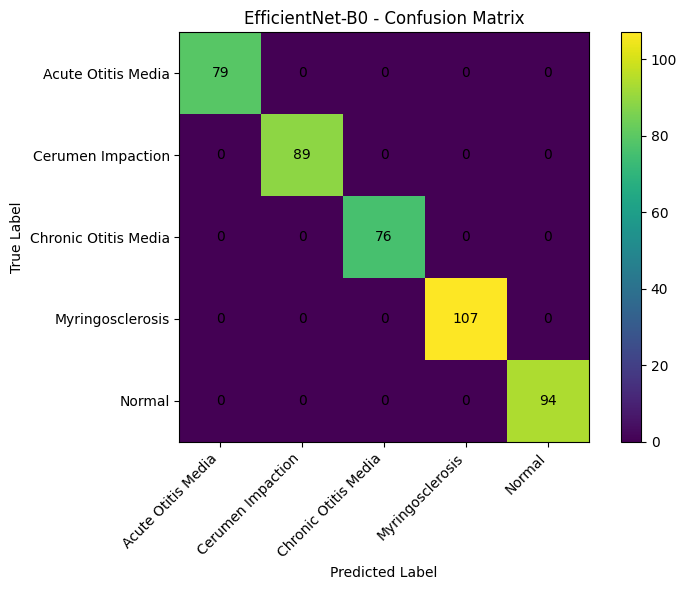

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(efficient_cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B0 - Confusion Matrix")

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            efficient_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

**DenseNet121**

In [122]:
from torchvision.models import densenet121, DenseNet121_Weights
import torch.nn as nn

weights = DenseNet121_Weights.DEFAULT

densenet = densenet121(weights=weights)

num_features = densenet.classifier.in_features

densenet.classifier = nn.Linear(
    num_features,
    NUM_CLASSES
)

densenet = densenet.to(device)

print(densenet.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 121MB/s]


Linear(in_features=1024, out_features=5, bias=True)


In [123]:
dense_criterion = nn.CrossEntropyLoss()

dense_optimizer = torch.optim.AdamW(
    densenet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

dense_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    dense_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [124]:
dense_train_losses = []
dense_train_accuracies = []

dense_val_losses = []
dense_val_accuracies = []

dense_best_val_loss = float("inf")
dense_best_model_state = None

NUM_EPOCHS = 5

import copy
import time

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        densenet,
        train_loader,
        dense_criterion,
        dense_optimizer,
        device
    )

    val_loss, val_acc = validate(
        densenet,
        val_loader,
        dense_criterion,
        device
    )

    dense_scheduler.step(val_loss)

    dense_train_losses.append(train_loss)
    dense_train_accuracies.append(train_acc)

    dense_val_losses.append(val_loss)
    dense_val_accuracies.append(val_acc)

    if val_loss < dense_best_val_loss:

        dense_best_val_loss = val_loss

        dense_best_model_state = copy.deepcopy(
            densenet.state_dict()
        )

    current_lr = dense_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/5] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

training_time = (time.time() - start_time) / 60

print(f"\nTraining time: {training_time:.2f} minutes")
print(f"Best validation loss: {dense_best_val_loss:.6f}")

Epoch [1/5] | Train Loss: 0.3584 | Train Acc: 90.72% | Val Loss: 0.0764 | Val Acc: 98.33% | LR: 0.000100
Epoch [2/5] | Train Loss: 0.0502 | Train Acc: 98.64% | Val Loss: 0.0250 | Val Acc: 100.00% | LR: 0.000100
Epoch [3/5] | Train Loss: 0.0253 | Train Acc: 99.51% | Val Loss: 0.0113 | Val Acc: 100.00% | LR: 0.000100
Epoch [4/5] | Train Loss: 0.0214 | Train Acc: 99.32% | Val Loss: 0.0076 | Val Acc: 100.00% | LR: 0.000100
Epoch [5/5] | Train Loss: 0.0125 | Train Acc: 99.90% | Val Loss: 0.0151 | Val Acc: 99.76% | LR: 0.000100

Training time: 2.21 minutes
Best validation loss: 0.007582


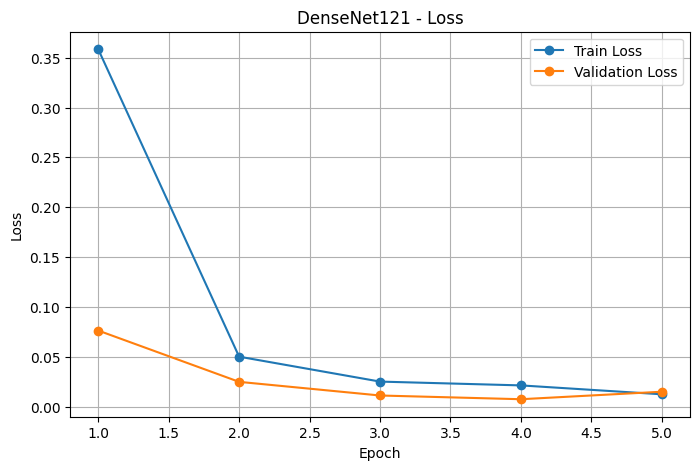

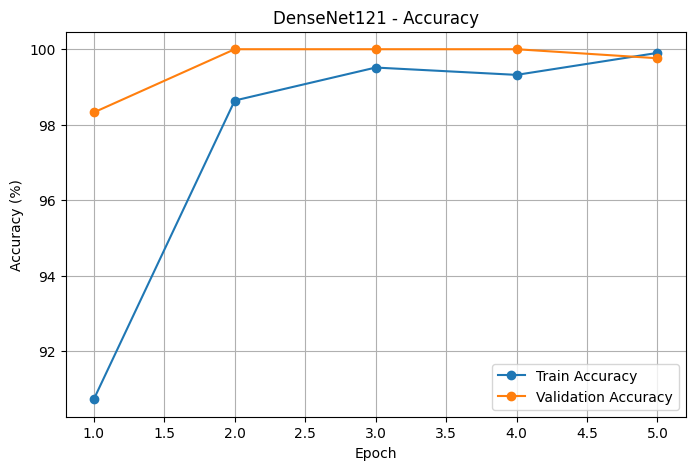

In [126]:
import matplotlib.pyplot as plt

epochs = range(1, len(dense_train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    dense_train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    dense_val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 - Loss")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in dense_train_accuracies],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in dense_val_accuracies],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("DenseNet121 - Accuracy")
plt.legend()
plt.grid()

plt.show()

In [127]:
TOTAL_EPOCHS = 20
PATIENCE = 4

dense_best_val_loss = min(dense_val_losses)

dense_best_model_state = copy.deepcopy(
    densenet.state_dict()
)

dense_epochs_without_improvement = 0

start_epoch = 5

for epoch in range(start_epoch, TOTAL_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        densenet,
        train_loader,
        dense_criterion,
        dense_optimizer,
        device
    )

    val_loss, val_acc = validate(
        densenet,
        val_loader,
        dense_criterion,
        device
    )

    dense_scheduler.step(val_loss)

    dense_train_losses.append(train_loss)
    dense_train_accuracies.append(train_acc)

    dense_val_losses.append(val_loss)
    dense_val_accuracies.append(val_acc)

    if val_loss < dense_best_val_loss:

        dense_best_val_loss = val_loss

        dense_best_model_state = copy.deepcopy(
            densenet.state_dict()
        )

        dense_epochs_without_improvement = 0

        best_marker = " <-- BEST"

    else:

        dense_epochs_without_improvement += 1

        best_marker = ""

    current_lr = dense_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
        f"{best_marker}"
    )

    if dense_epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break

Epoch [6/20] | Train Loss: 0.0084 | Train Acc: 100.00% | Val Loss: 0.0406 | Val Acc: 98.09% | LR: 0.000100
Epoch [7/20] | Train Loss: 0.0056 | Train Acc: 99.95% | Val Loss: 0.0148 | Val Acc: 99.76% | LR: 0.000050
Epoch [8/20] | Train Loss: 0.0099 | Train Acc: 99.71% | Val Loss: 0.0372 | Val Acc: 98.56% | LR: 0.000050
Epoch [9/20] | Train Loss: 0.0063 | Train Acc: 99.90% | Val Loss: 0.0062 | Val Acc: 99.76% | LR: 0.000050 <-- BEST
Epoch [10/20] | Train Loss: 0.0028 | Train Acc: 100.00% | Val Loss: 0.0024 | Val Acc: 100.00% | LR: 0.000050 <-- BEST
Epoch [11/20] | Train Loss: 0.0032 | Train Acc: 99.95% | Val Loss: 0.0015 | Val Acc: 100.00% | LR: 0.000050 <-- BEST
Epoch [12/20] | Train Loss: 0.0031 | Train Acc: 100.00% | Val Loss: 0.0012 | Val Acc: 100.00% | LR: 0.000050 <-- BEST
Epoch [13/20] | Train Loss: 0.0114 | Train Acc: 99.66% | Val Loss: 0.0347 | Val Acc: 98.56% | LR: 0.000050
Epoch [14/20] | Train Loss: 0.0041 | Train Acc: 100.00% | Val Loss: 0.0023 | Val Acc: 100.00% | LR: 0.0000

In [128]:
densenet.load_state_dict(
    dense_best_model_state
)

torch.save(
    densenet.state_dict(),
    "/content/densenet121_leakage_safe_best.pth"
)

print("Best DenseNet121 checkpoint saved.")
print(
    "Best validation loss:",
    dense_best_val_loss
)

Best DenseNet121 checkpoint saved.
Best validation loss: 0.001167208061310681


In [129]:
densenet.load_state_dict(
    dense_best_model_state
)

densenet.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [130]:
dense_all_labels = []
dense_all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = densenet(images)

        predictions = torch.argmax(outputs, dim=1)

        dense_all_labels.extend(
            labels.cpu().numpy()
        )

        dense_all_predictions.extend(
            predictions.cpu().numpy()
        )

In [131]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

dense_test_accuracy = accuracy_score(
    dense_all_labels,
    dense_all_predictions
)

print(
    f"DenseNet121 Test Accuracy: "
    f"{dense_test_accuracy * 100:.2f}%"
)

DenseNet121 Test Accuracy: 100.00%


In [132]:
print(
    classification_report(
        dense_all_labels,
        dense_all_predictions,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    1.0000    1.0000        79
   Cerumen Impaction     1.0000    1.0000    1.0000        89
Chronic Otitis Media     1.0000    1.0000    1.0000        76
    Myringosclerosis     1.0000    1.0000    1.0000       107
              Normal     1.0000    1.0000    1.0000        94

            accuracy                         1.0000       445
           macro avg     1.0000    1.0000    1.0000       445
        weighted avg     1.0000    1.0000    1.0000       445



Confusion Matrix:
[[ 79   0   0   0   0]
 [  0  89   0   0   0]
 [  0   0  76   0   0]
 [  0   0   0 107   0]
 [  0   0   0   0  94]]


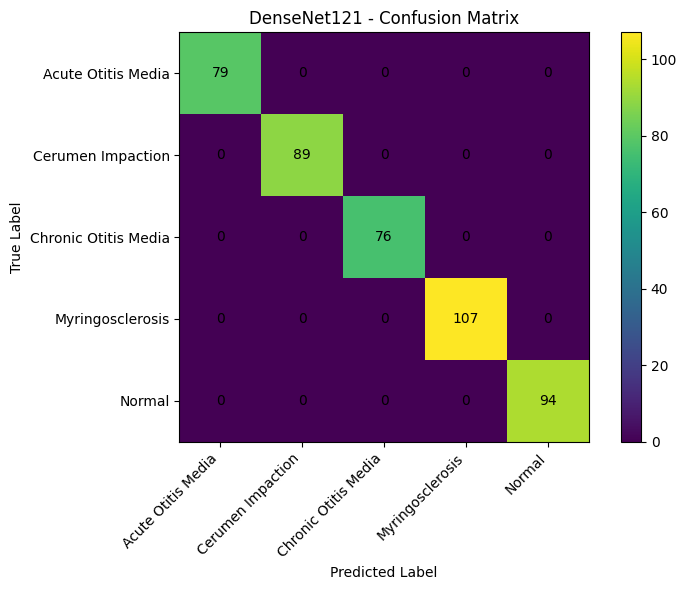

In [133]:
dense_cm = confusion_matrix(
    dense_all_labels,
    dense_all_predictions
)

print("Confusion Matrix:")
print(dense_cm)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(dense_cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DenseNet121 - Confusion Matrix")

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            dense_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

**Compare model complexity**

In [134]:
def count_parameters(model):
    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


models = {
    "ResNet18": model,
    "MobileNetV3-Large": mobilenet,
    "EfficientNet-B0": efficientnet,
    "DenseNet121": densenet
}

for name, current_model in models.items():

    total, trainable = count_parameters(current_model)

    print(
        f"{name}: "
        f"{total:,} total parameters | "
        f"{trainable:,} trainable parameters"
    )

ResNet18: 11,179,077 total parameters | 11,179,077 trainable parameters
MobileNetV3-Large: 4,208,437 total parameters | 4,208,437 trainable parameters
EfficientNet-B0: 4,013,953 total parameters | 4,013,953 trainable parameters
DenseNet121: 6,958,981 total parameters | 6,958,981 trainable parameters


In [135]:
import os

model_paths = {
    "ResNet18": "/content/resnet18_leakage_safe_best.pth",
    "MobileNetV3-Large": "/content/mobilenet_v3_large_leakage_safe_best.pth",
    "EfficientNet-B0": "/content/efficientnet_b0_leakage_safe_best.pth",
    "DenseNet121": "/content/densenet121_leakage_safe_best.pth"
}

for name, path in model_paths.items():

    size_mb = os.path.getsize(path) / (1024 ** 2)

    print(
        f"{name}: {size_mb:.2f} MB"
    )

ResNet18: 42.72 MB
MobileNetV3-Large: 16.26 MB
EfficientNet-B0: 15.61 MB
DenseNet121: 27.14 MB


Recorded Training time
| Model | Initial 5 epochs |
|---|---:|
| ResNet18 | 1.29 min |
| MobileNetV3-Large | 1.36 min |
| EfficientNet-B0 | 1.50 min |
| DenseNet121 | 2.21 min |

Current model comparison
| Model | Test Accuracy | Parameters | Model Size |
|---|---:|---:|---:|
| ResNet18 | 99.78% | 11.18M | 42.72 MB |
| MobileNetV3-Large | **100.00%** | 4.21M | 16.26 MB |
| EfficientNet-B0 | **100.00%** | **4.01M** | **15.61 MB** |
| DenseNet121 | **100.00%** | 6.96M | 27.14 MB |

MobileNetV3-Large = EfficientNet-B0 = DenseNet121 > ResNet18

**Measure inference speed**

In [136]:
import time
import torch


def measure_inference_time(model, loader, device):

    model.eval()

    # Warm-up
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            _ = model(images)
            break

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    total_images = 0

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            _ = model(images)

            total_images += images.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize()

    total_time = time.time() - start_time

    images_per_second = total_images / total_time

    ms_per_image = (total_time / total_images) * 1000

    return total_time, images_per_second, ms_per_image

In [137]:
inference_results = {}

for name, current_model in models.items():

    total_time, images_per_second, ms_per_image = \
        measure_inference_time(
            current_model,
            test_loader,
            device
        )

    inference_results[name] = {
        "total_time": total_time,
        "images_per_second": images_per_second,
        "ms_per_image": ms_per_image
    }

    print(
        f"{name}: "
        f"{total_time:.4f} sec | "
        f"{images_per_second:.2f} images/sec | "
        f"{ms_per_image:.2f} ms/image"
    )

ResNet18: 2.7024 sec | 164.67 images/sec | 6.07 ms/image
MobileNetV3-Large: 2.4177 sec | 184.06 images/sec | 5.43 ms/image
EfficientNet-B0: 2.1491 sec | 207.06 images/sec | 4.83 ms/image
DenseNet121: 2.6207 sec | 169.80 images/sec | 5.89 ms/image


Benchmark Comparison
| Model | Test Accuracy | Parameters | Model Size | Inference |
|---|---:|---:|---:|---:|
| ResNet18 | 99.78% | 11.18M | 42.72 MB | 6.07 ms/image |
| MobileNetV3-Large | **100.00%** | 4.21M | 16.26 MB | 5.43 ms/image |
| **EfficientNet-B0** | **100.00%** | **4.01M** | **15.61 MB** | **4.83 ms/image** |
| DenseNet121 | **100.00%** | 6.96M | 27.14 MB | 5.89 ms/image |

# **EfficientNet-B0 was selected as the best-performing model under the experimental setup based on test accuracy, parameter count, model size, and inference speed.**

**Final robustness check**

In [138]:
import torch
import numpy as np

efficientnet.load_state_dict(
    efficient_best_model_state
)

efficientnet.eval()

confidences = []
predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = efficientnet(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

        confidences.extend(
            confidence.cpu().numpy()
        )

        predictions.extend(
            predicted.cpu().numpy()
        )

        true_labels.extend(
            labels.numpy()
        )

confidences = np.array(confidences)
predictions = np.array(predictions)
true_labels = np.array(true_labels)

print("Minimum confidence:",
      confidences.min())

print("Maximum confidence:",
      confidences.max())

print("Mean confidence:",
      confidences.mean())

print("Median confidence:",
      np.median(confidences))

Minimum confidence: 0.9967932
Maximum confidence: 1.0
Mean confidence: 0.99992484
Median confidence: 0.9999796


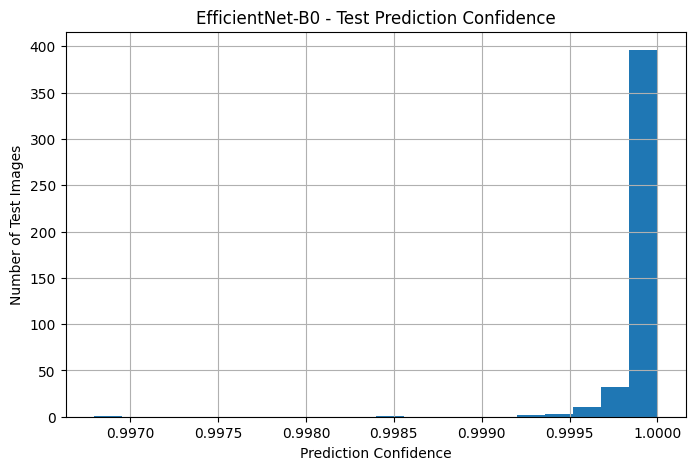

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    confidences,
    bins=20
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Test Images")
plt.title("EfficientNet-B0 - Test Prediction Confidence")

plt.grid()

plt.show()

In [140]:
for threshold in [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]:

    count = np.sum(
        confidences < threshold
    )

    print(
        f"Confidence < {threshold:.2f}: "
        f"{count} / {len(confidences)}"
    )

Confidence < 0.50: 0 / 445
Confidence < 0.70: 0 / 445
Confidence < 0.80: 0 / 445
Confidence < 0.90: 0 / 445
Confidence < 0.95: 0 / 445
Confidence < 0.99: 0 / 445


**Robustness test**

In [141]:
robustness_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [142]:
robustness_dataset = EarDataset(
    test_df,
    transform=robustness_transform
)

robustness_loader = DataLoader(
    robustness_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [143]:
efficientnet.load_state_dict(
    efficient_best_model_state
)

efficientnet.eval()

robust_labels = []
robust_predictions = []

with torch.no_grad():

    for images, labels in robustness_loader:

        images = images.to(device)

        outputs = efficientnet(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        robust_labels.extend(
            labels.numpy()
        )

        robust_predictions.extend(
            predictions.cpu().numpy()
        )

In [144]:
robust_accuracy = accuracy_score(
    robust_labels,
    robust_predictions
)

print(
    f"Robustness Test Accuracy: "
    f"{robust_accuracy * 100:.2f}%"
)

Robustness Test Accuracy: 100.00%


**Grad-CAM Explainability**

In [145]:
efficientnet.load_state_dict(
    efficient_best_model_state
)

efficientnet.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [146]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

target_layer = efficientnet.features[-1]

activations = None
gradients = None


def forward_hook(module, input, output):
    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]


forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

In [147]:
def generate_gradcam(model, image, target_class):

    global activations
    global gradients

    model.zero_grad()

    image = image.unsqueeze(0).to(device)

    output = model(image)

    score = output[0, target_class]

    score.backward()

    # Feature-map gradients
    grads = gradients[0]

    # Feature-map activations
    acts = activations[0]

    # Global average pooling of gradients
    weights = grads.mean(
        dim=(1, 2)
    )

    # Weighted combination
    cam = torch.zeros(
        acts.shape[1:],
        device=device
    )

    for i, weight in enumerate(weights):
        cam += weight * acts[i]

    cam = F.relu(cam)

    cam -= cam.min()

    if cam.max() > 0:
        cam /= cam.max()

    cam = cam.detach().cpu().numpy()

    return cam

In [151]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_gradcam(
    image_tensor,
    cam,
    true_label,
    predicted_label
):

    # -----------------------------
    # Convert normalized tensor
    # back to displayable image
    # -----------------------------

    image = image_tensor.permute(
        1, 2, 0
    ).cpu().numpy()

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    image = image * std + mean

    image = np.clip(
        image,
        0,
        1
    )

    # -----------------------------
    # Resize CAM to image size
    # -----------------------------

    cam_resized = cv2.resize(
        cam,
        (image.shape[1], image.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )

    # Normalize CAM
    cam_resized = np.maximum(
        cam_resized,
        0
    )

    if cam_resized.max() > 0:
        cam_resized = (
            cam_resized /
            cam_resized.max()
        )

    # -----------------------------
    # Create heatmap
    # -----------------------------

    heatmap = plt.get_cmap("jet")(
        cam_resized
    )[:, :, :3]

    # -----------------------------
    # Overlay
    # -----------------------------

    overlay = (
        0.6 * image +
        0.4 * heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    # -----------------------------
    # Plot
    # -----------------------------

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)

    plt.imshow(image)

    plt.title("Original Image")

    plt.axis("off")

    plt.subplot(1, 3, 2)

    plt.imshow(
        cam_resized,
        cmap="jet"
    )

    plt.title("Grad-CAM")

    plt.axis("off")

    plt.colorbar(
        fraction=0.046,
        pad=0.04
    )

    plt.subplot(1, 3, 3)

    plt.imshow(overlay)

    plt.title(
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

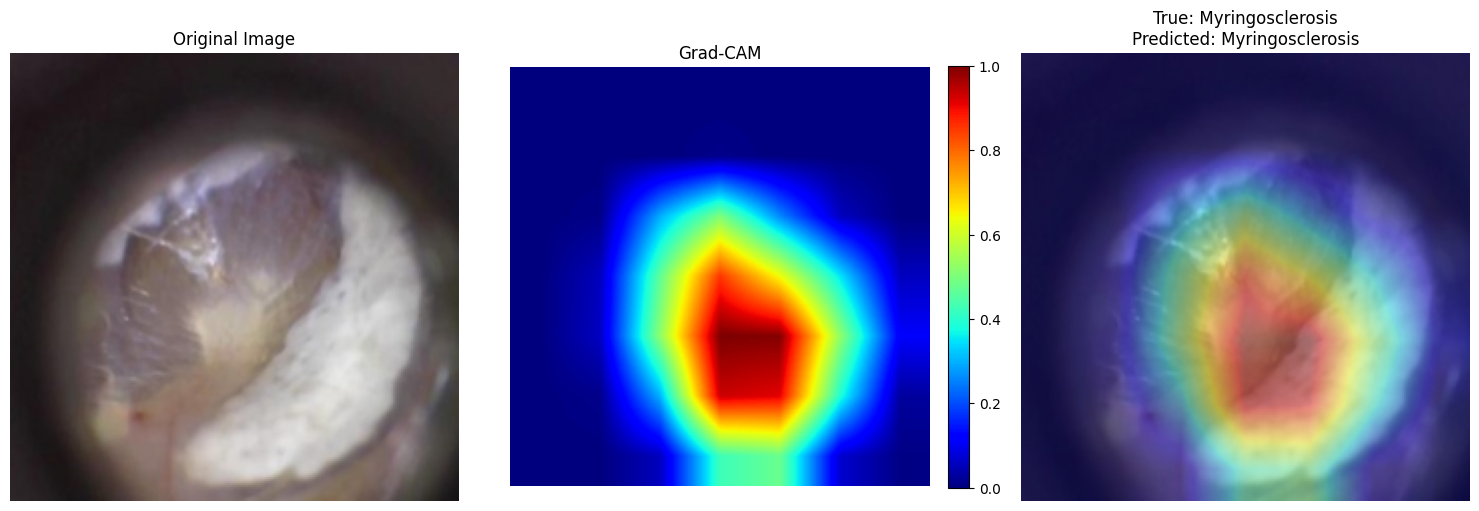

In [152]:
image, label = test_dataset[0]

efficientnet.eval()

with torch.no_grad():

    output = efficientnet(
        image.unsqueeze(0).to(device)
    )

    prediction = torch.argmax(
        output,
        dim=1
    ).item()

cam = generate_gradcam(
    efficientnet,
    image,
    prediction
)

show_gradcam(
    image,
    cam,
    class_names[label],
    class_names[prediction]
)

**Generate Grad-CAM for all 5 classes**

In [153]:
import matplotlib.pyplot as plt
import numpy as np
import torch


def denormalize_image(image_tensor):

    image = image_tensor.permute(
        1, 2, 0
    ).cpu().numpy()

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    image = image * std + mean

    return np.clip(image, 0, 1)

In [154]:
selected_samples = {}

efficientnet.eval()

for index in range(len(test_dataset)):

    image, true_label = test_dataset[index]

    with torch.no_grad():

        output = efficientnet(
            image.unsqueeze(0).to(device)
        )

        prediction = torch.argmax(
            output,
            dim=1
        ).item()

    if prediction == true_label:

        if true_label not in selected_samples:

            selected_samples[true_label] = (
                index,
                image,
                prediction
            )

    if len(selected_samples) == NUM_CLASSES:
        break


for label_id, data in selected_samples.items():

    index, image, prediction = data

    print(
        f"{class_names[label_id]} "
        f"→ test index {index}"
    )

Myringosclerosis → test index 0
Chronic Otitis Media → test index 1
Cerumen Impaction → test index 2
Acute Otitis Media → test index 6
Normal → test index 11


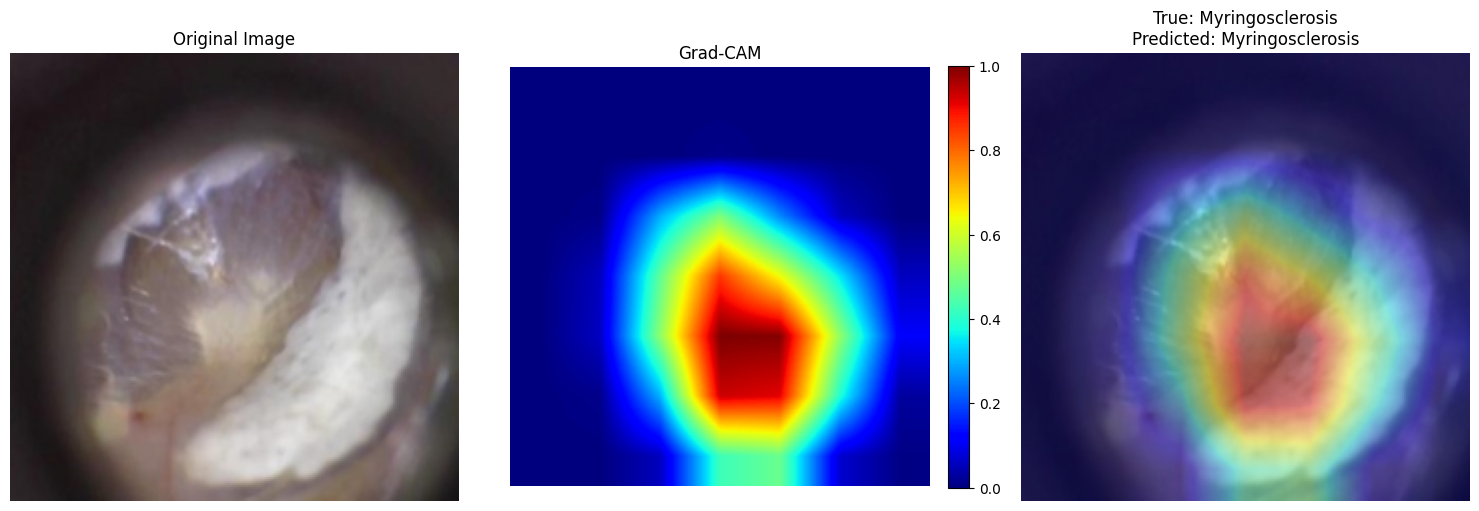

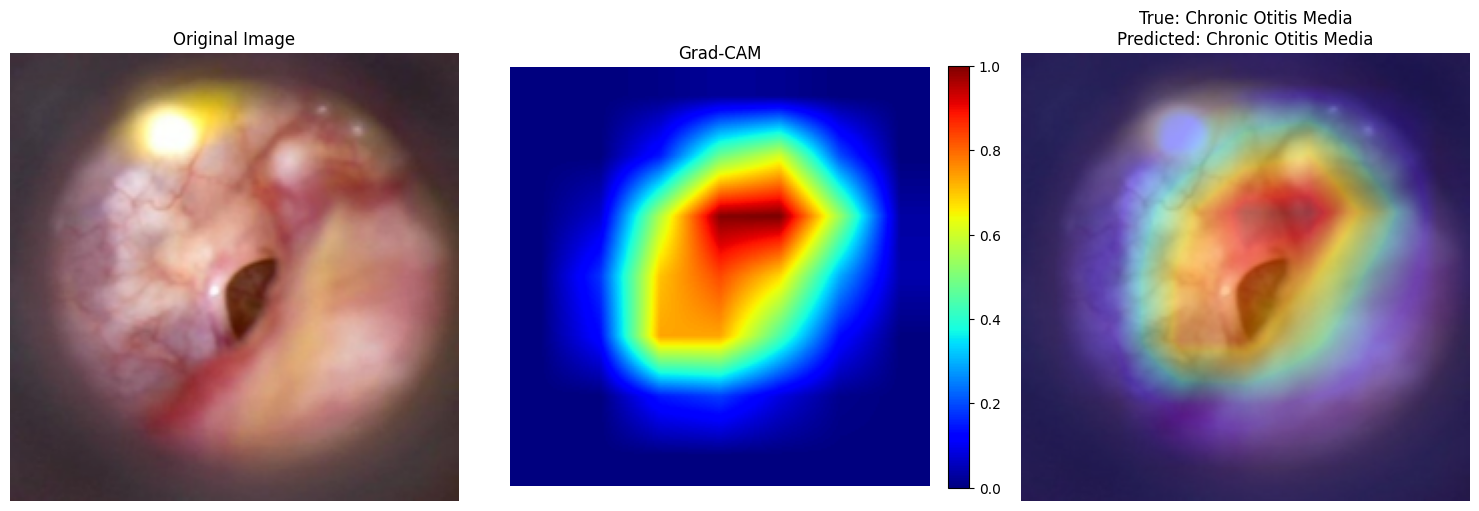

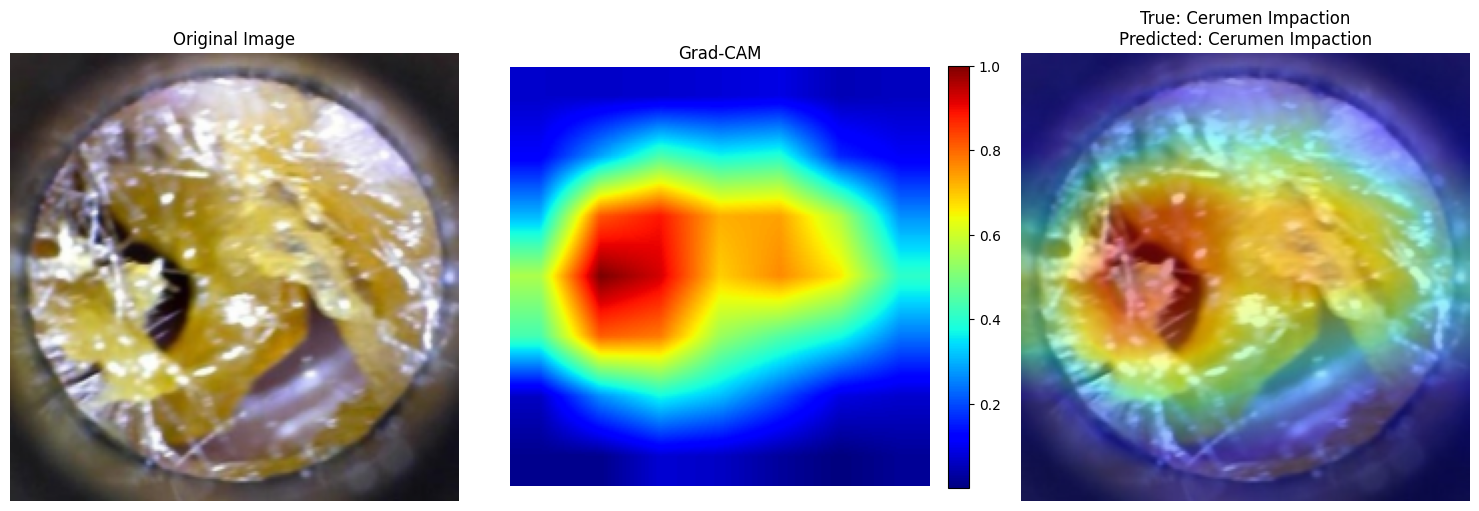

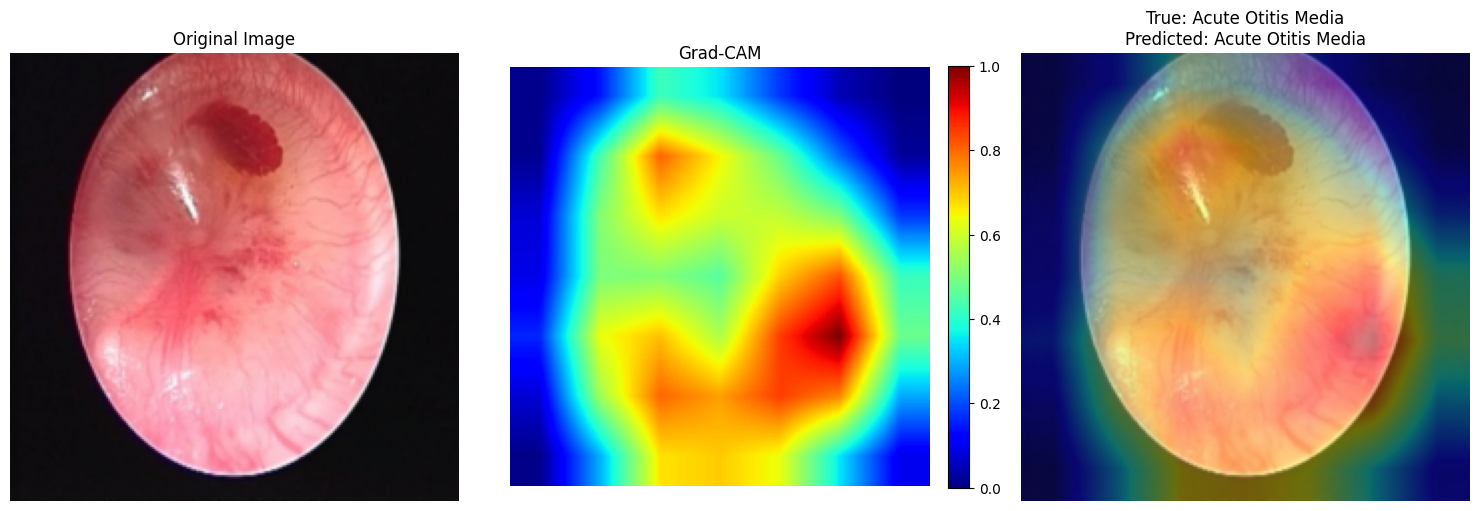

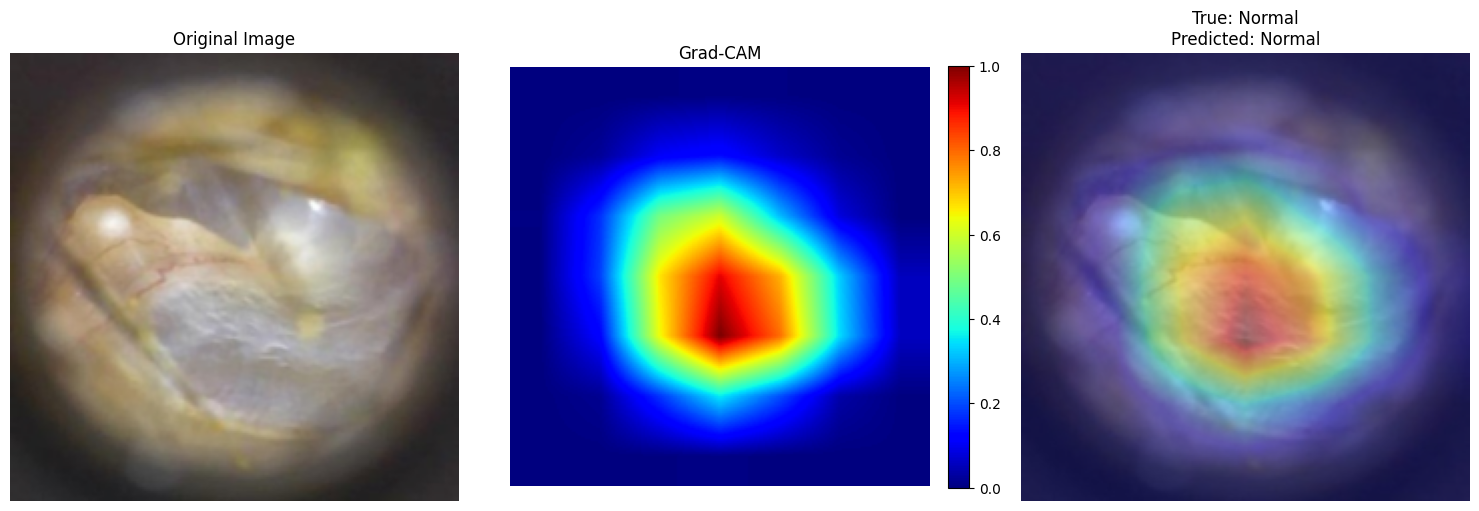

In [155]:
for label_id, data in selected_samples.items():

    index, image, prediction = data

    cam = generate_gradcam(
        efficientnet,
        image,
        prediction
    )

    show_gradcam(
        image,
        cam,
        class_names[label_id],
        class_names[prediction]
    )

Grad-CAM analysis was performed on representative correctly classified samples from all five classes. The generated heatmaps generally showed that EfficientNet-B0 focused on the central otoscopic region containing the tympanic membrane and class-relevant visual structures rather than predominantly attending to the image background. For Cerumen Impaction, the activation notably overlapped the visible cerumen region, while the Otitis Media and Myringosclerosis examples showed activation concentrated over relevant regions of the tympanic membrane. The Normal example also showed attention primarily within the ear region. These visualizations provide qualitative evidence of model interpretability, although they do not constitute clinical validation.

**Save the final model + class mapping**

In [156]:
import torch
import json
import os

# Load the best EfficientNet-B0 checkpoint
efficientnet.load_state_dict(
    efficient_best_model_state
)

efficientnet.eval()

# Create model directory
model_dir = "/content/ear_disease_model"
os.makedirs(model_dir, exist_ok=True)

# Save model weights
model_path = os.path.join(
    model_dir,
    "efficientnet_b0_ear_disease.pth"
)

torch.save(
    efficientnet.state_dict(),
    model_path
)

# Class mapping
class_mapping = {
    int(row["label_id"]): row["label"]
    for _, row in train_df.iterrows()
}

# Remove duplicates while preserving mapping
class_mapping = {
    int(k): v
    for k, v in class_mapping.items()
}

mapping_path = os.path.join(
    model_dir,
    "class_mapping.json"
)

with open(mapping_path, "w") as f:
    json.dump(
        class_mapping,
        f,
        indent=4
    )

print("Model saved to:", model_path)
print("Class mapping saved to:", mapping_path)
print("\nClass mapping:")
print(json.dumps(class_mapping, indent=4))

Model saved to: /content/ear_disease_model/efficientnet_b0_ear_disease.pth
Class mapping saved to: /content/ear_disease_model/class_mapping.json

Class mapping:
{
    "2": "Chronic Otitis Media",
    "0": "Acute Otitis Media",
    "4": "Normal",
    "1": "Cerumen Impaction",
    "3": "Myringosclerosis"
}


In [157]:
from PIL import Image
import torch
import torch.nn.functional as F


def predict_ear_disease(
    image_path,
    model,
    device
):

    model.eval()

    # Load image
    image = Image.open(
        image_path
    ).convert("RGB")

    # Apply same preprocessing used for validation/test
    input_tensor = val_test_transform(
        image
    )

    # Add batch dimension
    input_tensor = input_tensor.unsqueeze(0)

    # Move to device
    input_tensor = input_tensor.to(device)

    # Prediction
    with torch.no_grad():

        outputs = model(
            input_tensor
        )

        probabilities = F.softmax(
            outputs,
            dim=1
        )

        confidence, predicted_class = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = predicted_class.item()

    confidence = confidence.item()

    # All class probabilities
    probabilities = probabilities[0].cpu().numpy()

    results = {
        "predicted_class": predicted_class,
        "predicted_label": class_mapping[predicted_class],
        "confidence": confidence,
        "probabilities": {
            class_mapping[i]: float(probabilities[i])
            for i in range(NUM_CLASSES)
        }
    }

    return results

In [158]:
test_image_path = test_df.iloc[0]["image_path"]

result = predict_ear_disease(
    test_image_path,
    efficientnet,
    device
)

print(result)

{'predicted_class': 3, 'predicted_label': 'Myringosclerosis', 'confidence': 0.9999969005584717, 'probabilities': {'Acute Otitis Media': 1.4905684508903505e-07, 'Cerumen Impaction': 7.1357504793923e-07, 'Chronic Otitis Media': 5.545474550672225e-07, 'Myringosclerosis': 0.9999969005584717, 'Normal': 1.6899159618333215e-06}}


In [159]:
import shutil

zip_path = shutil.make_archive(
    "/content/ear_disease_model",
    "zip",
    "/content/ear_disease_model"
)

print("Created:", zip_path)

Created: /content/ear_disease_model.zip


In [219]:
from google.colab import files

uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]

print("Uploaded image:", uploaded_filename)


Saving mys (124).jpg to mys (124) (1).jpg
Uploaded image: mys (124) (1).jpg


In [220]:
result = predict_ear_disease(
    uploaded_filename,
    efficientnet,
    device
)

print("\nPrediction Result")
print("-" * 40)

print("Predicted Disease:",
      result["predicted_label"])

print("Confidence:",
      f"{result['confidence'] * 100:.4f}%")

print("\nClass Probabilities:")

for label, probability in result["probabilities"].items():

    print(
        f"{label}: "
        f"{probability * 100:.4f}%"
    )


Prediction Result
----------------------------------------
Predicted Disease: Myringosclerosis
Confidence: 99.9994%

Class Probabilities:
Acute Otitis Media: 0.0000%
Cerumen Impaction: 0.0001%
Chronic Otitis Media: 0.0005%
Myringosclerosis: 99.9994%
Normal: 0.0001%


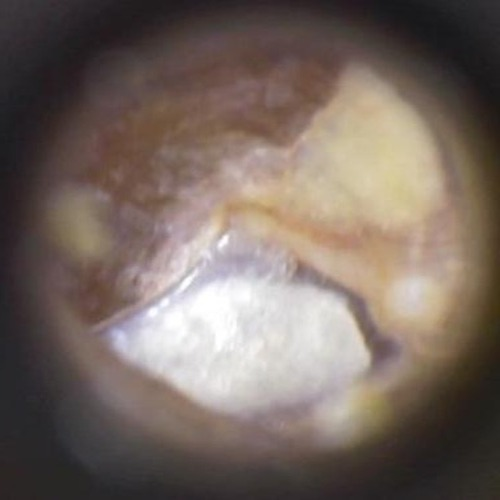

In [221]:
from IPython.display import display
from PIL import Image

uploaded_image = Image.open(
    uploaded_filename
).convert("RGB")

display(uploaded_image)

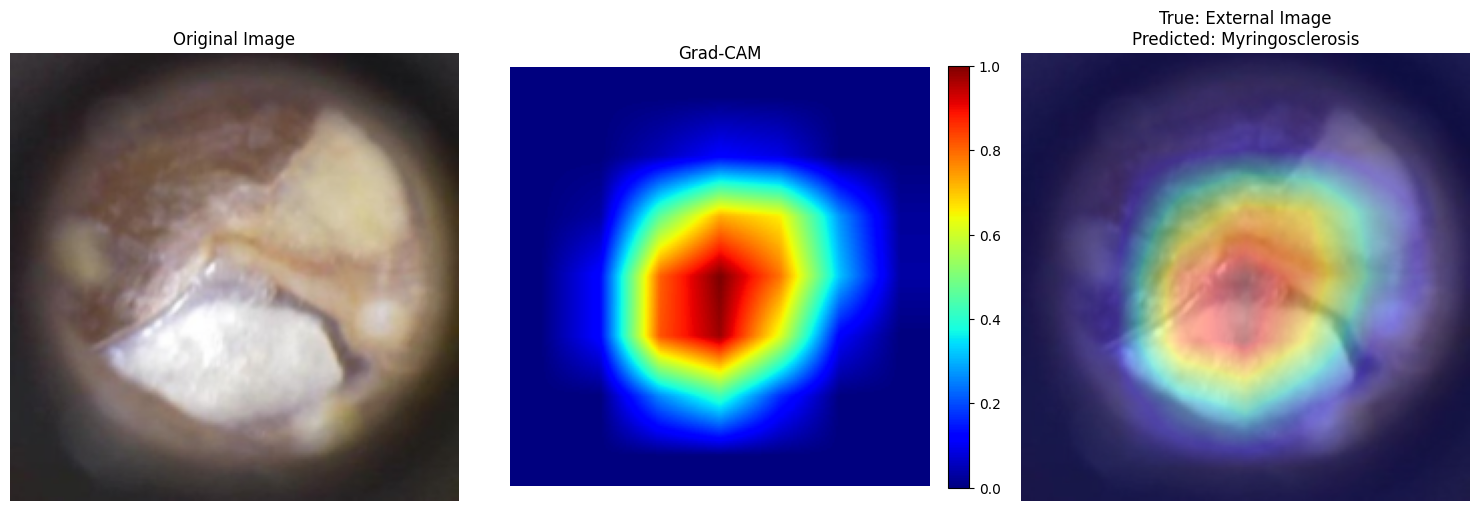

In [222]:
image_tensor = val_test_transform(
    uploaded_image
)

# Prediction
efficientnet.eval()

with torch.no_grad():

    output = efficientnet(
        image_tensor.unsqueeze(0).to(device)
    )

    prediction = torch.argmax(
        output,
        dim=1
    ).item()

# Grad-CAM
cam = generate_gradcam(
    efficientnet,
    image_tensor,
    prediction
)

show_gradcam(
    image_tensor,
    cam,
    "External Image",
    class_names[prediction]
)

In [223]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

NUM_CLASSES = 5

CLASS_NAMES = {
    0: "Acute Otitis Media",
    1: "Cerumen Impaction",
    2: "Chronic Otitis Media",
    3: "Myringosclerosis",
    4: "Normal"
}


def load_model(model_path, device):

    model = efficientnet_b0(
        weights=None
    )

    num_features = model.classifier[-1].in_features

    model.classifier[-1] = nn.Linear(
        num_features,
        NUM_CLASSES
    )

    checkpoint = torch.load(
        model_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint
    )

    model = model.to(device)

    model.eval()

    return model

In [224]:
from torchvision import transforms

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [225]:
from PIL import Image
import torch
import torch.nn.functional as F


def predict_image(
    image_path,
    model,
    device
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = inference_transform(
        image
    )

    input_tensor = image_tensor.unsqueeze(
        0
    ).to(device)

    with torch.no_grad():

        outputs = model(
            input_tensor
        )

        probabilities = F.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

    predicted_id = predicted.item()

    confidence = confidence.item()

    probabilities = probabilities[
        0
    ].cpu().numpy()

    return {
        "prediction": CLASS_NAMES[predicted_id],
        "confidence": confidence,
        "probabilities": {
            CLASS_NAMES[i]: float(
                probabilities[i]
            )
            for i in range(NUM_CLASSES)
        }
    }

In [226]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = load_model(
    "/content/ear_disease_model/efficientnet_b0_ear_disease.pth",
    device
)

result = predict_image(
    test_image_path,
    model,
    device
)

print(result)

{'prediction': 'Myringosclerosis', 'confidence': 0.9999969005584717, 'probabilities': {'Acute Otitis Media': 1.4905684508903505e-07, 'Cerumen Impaction': 7.1357504793923e-07, 'Chronic Otitis Media': 5.545474550672225e-07, 'Myringosclerosis': 0.9999969005584717, 'Normal': 1.6899159618333215e-06}}
